# PD Analysis (Modular)

This notebook is a concise entry point. All heavy lifting lives in `pd_pipeline/`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd

from pd_pipeline import basel, capital, config, data, lasso, plots, portfolio, scenario, sensitivity


In [2]:
# Load and merge macro + GPR data
macro_frames = data.load_macro_data(
    gdp_path      = '../data/macro/global_gdp_monthly.csv',
    interest_path = '../data/macro/intrest FRED.csv',
    brent_path    = '../data/macro/brent_oil_monthly.csv',
    fuel_path     = '../data/macro/fuel_index_monthly.csv',
    cpi_path      = '../data/macro/global_cpi_monthly.csv',
    verbose       = True,
)

df_gpr = data.load_gpr_data('../data/geopolitical/data_gpr_Data_GPR.csv', verbose=True)

df_merged = data.merge_macro_data(macro_frames, df_gpr)

# Covariance / correlation on unlagged variables only (used for scenario analysis)
cov_matrix, corr_matrix, mean_vector = data.summarize_macro_data(
    df_merged,
    config.ALL_PREDICTOR_COLS,
    verbose=True,
)

# Add t-1 … t-12 lags for all macro + GPR variables
df_merged = data.add_macro_lags(df_merged, config.MACRO_COLS + config.GPR_COLS, n_lags=config.N_LAGS)
print(f"df_merged now has {df_merged.shape[1]} columns ({config.N_LAGS} lags added per variable)")

Cleaned df_gdp head:
        Date  GDP_Growth
0 2012-01-01   95.266073
1 2012-02-01   95.453594
2 2012-03-01   95.641116
3 2012-04-01   95.828638
4 2012-05-01   95.974193

Cleaned df_interest head:
        Date  Interest_Rate
0 1954-07-01           0.80
1 1954-08-01           1.22
2 1954-09-01           1.07
3 1954-10-01           0.85
4 1954-11-01           0.83

Cleaned df_brent head:
        Date  Brent_Oil
0 1992-01-01  18.156522
1 1992-02-01  18.110000
2 1992-03-01  17.659091
3 1992-04-01  19.015909
4 1992-05-01  19.980952

Cleaned df_fuel head:
        Date  Fuel_Index
0 1992-01-01   46.771404
1 1992-02-01   46.927311
2 1992-03-01   47.083218
3 1992-04-01   47.239125
4 1992-05-01   47.178468

Cleaned df_cpi head:
        Date     CPI    Asia  Americas  Europe
0 2011-01-01  80.843  79.189    84.751  85.512
1 2011-02-01  81.250  79.557    85.168  85.956
2 2011-03-01  81.726  79.710    85.901  86.571
3 2011-04-01  82.164  80.058    86.387  87.002
4 2011-05-01  82.473  80.368    86.6

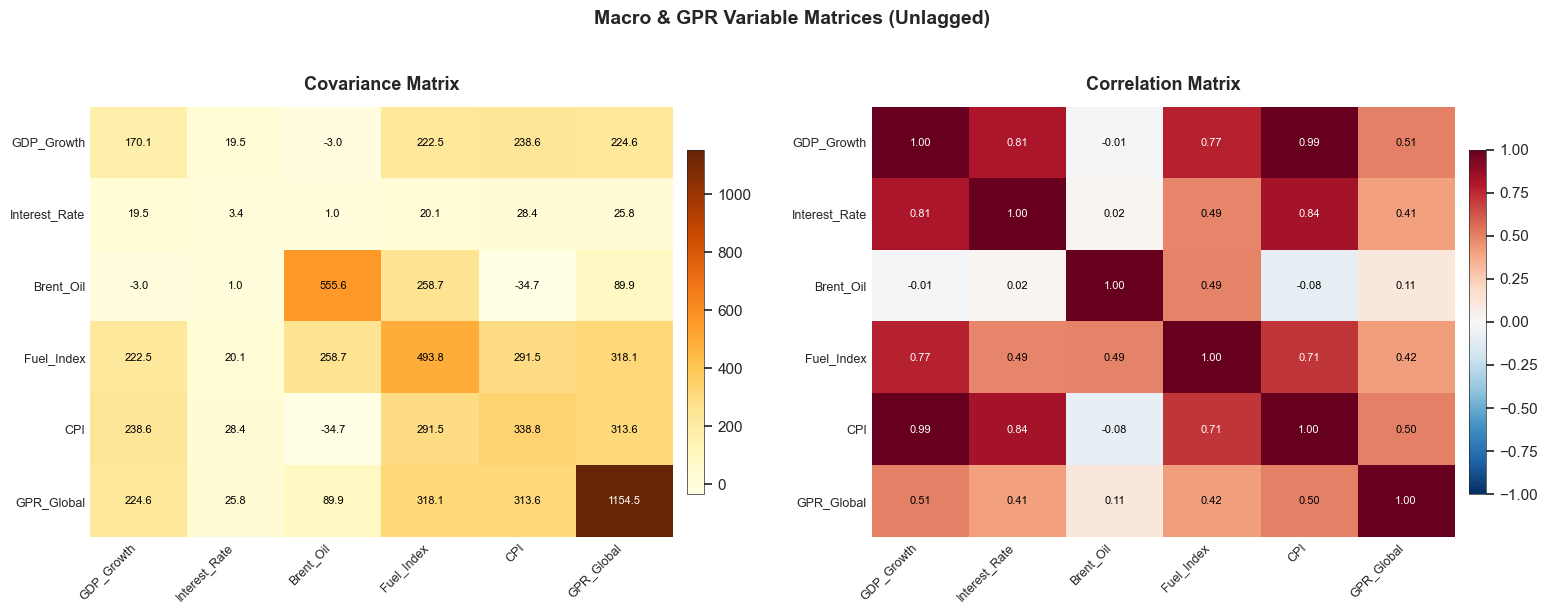

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

sns.set_theme(style='white', context='notebook')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

for ax, matrix, title in zip(
    axes,
    [cov_matrix, corr_matrix],
    ['Covariance Matrix', 'Correlation Matrix'],
):
    labels = matrix.columns.tolist()
    n = len(labels)
    vals = matrix.values

    vmax = 1.0 if 'Correlation' in title else None
    vmin = -1.0 if 'Correlation' in title else None
    cmap = 'RdBu_r' if 'Correlation' in title else 'YlOrBr'

    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.outline.set_linewidth(0.5)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(n):
        for j in range(n):
            v = vals[i, j]
            txt = f"{v:.2f}" if 'Correlation' in title else f"{v:.1f}"
            color = 'white' if abs(v) > (0.6 if 'Correlation' in title else 0.7 * vals.max()) else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

plt.suptitle('Macro & GPR Variable Matrices (Unlagged)', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

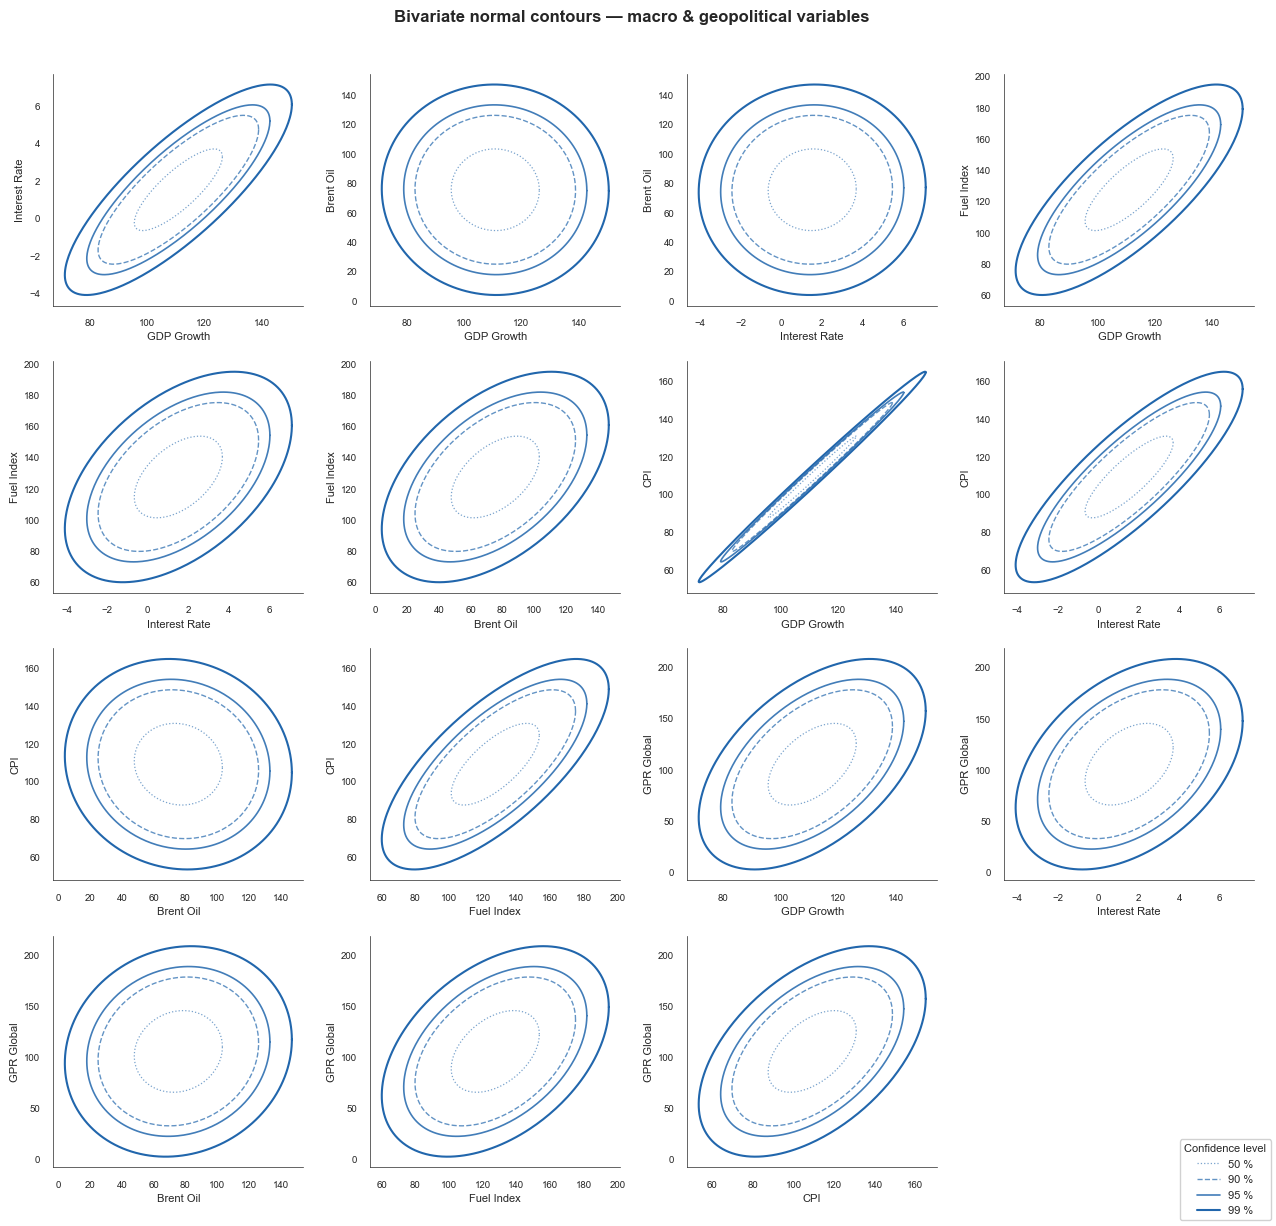

In [4]:
# Bivariate normal contour plots — all pairwise macro & geopolitical variable combinations
# Contours are derived from the covariance matrix (not historical data directly).
# Shows 50 %, 90 %, 95 %, and 99 % confidence ellipses of the fitted bivariate normal.

plots.plot_normal_contours_pairwise(
    cov_matrix=cov_matrix,
    mean_vector=mean_vector,
    cols=config.MACRO_COLS + config.GPR_COLS,
)

In [5]:
# Regenerate pdsFitchData_SIC_div2.csv with correct SIC div2 sector classification
# (Re-run this cell whenever the base PD data or sector mapping changes)
data.build_sic_div2_pds_file(
    pds_path='../data/PDs/pdsFitchData.csv',
    isin_path='../data/PDs/ISIN_PD_DATA.csv',
    output_path='../data/PDs/pdsFitchData_SIC_div2.csv',
    verbose=True,
)

# Load PDs and merge with macro data
df_pds = data.load_pds_data('../data/PDs/pdsFitchData_SIC_div2.csv', verbose=True)

df_final = data.merge_pds_macro(df_pds, df_merged, verbose=True)

# Drop rows where any current or lagged predictor is missing (removes first ~12 months per series)
df_final_cleaned = data.prepare_model_data(
    df_final,
    config.ALL_PREDICTOR_COLS_WITH_LAGS,
    sector_col=config.SECTOR_COL,
    verbose=True,
)


✓ Saved 49,022 rows to ../data/PDs/pdsFitchData_SIC_div2.csv

Sector distribution:
Sector
Finance, Insurance & Real Estate        12376
Heavy Manufacturing                      6858
Utilities                                5694
Light Manufacturing                      5657
Communications                           5268
Mining & Construction                    3104
Services                                 2914
Wholesale & Retail Trade                 2831
Unassigned                               1535
Transportation                           1444
Health, Legal & Educational Services      982
Public Administration                     359

Columns in df_pds: ['Company_number', 'Date', '12_month', 'Sector', 'PDzero']

First few rows of df_pds:
       Company_number       Date  12_month          Sector  PDzero
39773      80095907.0 2012-06-01    0.0050  Communications   0.005
39774      80095907.0 2012-06-01    0.0137  Communications   0.005
39775      80095907.0 2012-06-01    0.0137  Communi

In [6]:
# Export cleaned dataset for reuse
data.export_dataframe(df_final_cleaned, output_file='df_final_cleaned.csv', verbose=True)


✓ Successfully exported dataframe to: df_final_cleaned.csv
  - Rows: 49,022
  - Columns: 38
  - File size: 17.08 MB (approximate)


In [7]:
# ── df_final_cleaned verification ────────────────────────────────────────────
print("=" * 60)
print("df_final_cleaned  –  DATA VERIFICATION")
print("=" * 60)

print(f"\nShape : {df_final_cleaned.shape[0]:,} rows × {df_final_cleaned.shape[1]} columns")
print(f"Date range : {df_final_cleaned['Date'].min().date()}  →  {df_final_cleaned['Date'].max().date()}")
print(f"Companies  : {df_final_cleaned['Company_number'].nunique():,} unique")

if 'Sector' in df_final_cleaned.columns:
    print(f"\nSector distribution:")
    print(df_final_cleaned['Sector'].value_counts().to_string())

print("\nMissing values per column:")
missing = df_final_cleaned.isnull().sum()
missing = missing[missing > 0]
print(missing.to_string() if not missing.empty else "  None")

macro_cols = ['GDP_Growth', 'Interest_Rate', 'Brent_Oil', 'CPI',
              'GPR_Global']
available_macro = [c for c in macro_cols if c in df_final_cleaned.columns]
print(f"\nMacro summary ({', '.join(available_macro)}):")
print(df_final_cleaned[available_macro].describe().round(3).to_string())

print(f"\nPD (12_month) summary:")
print(df_final_cleaned['12_month'].describe().round(6).to_string())

print(f"\nFirst 5 rows:")
display_cols = ['Date', 'Company_number'] + (['Sector'] if 'Sector' in df_final_cleaned.columns else []) + ['12_month'] + available_macro[:3]
print(df_final_cleaned[display_cols].head(5).to_string(index=False))

df_final_cleaned  –  DATA VERIFICATION

Shape : 49,022 rows × 38 columns
Date range : 2012-06-01  →  2024-07-01
Companies  : 2,304 unique

Sector distribution:
Sector
Finance, Insurance & Real Estate        12376
Heavy Manufacturing                      6858
Utilities                                5694
Light Manufacturing                      5657
Communications                           5268
Mining & Construction                    3104
Services                                 2914
Wholesale & Retail Trade                 2831
Unassigned                               1535
Transportation                           1444
Health, Legal & Educational Services      982
Public Administration                     359

Missing values per column:
12_month    12157

Macro summary (GDP_Growth, Interest_Rate, Brent_Oil, CPI, GPR_Global):
       GDP_Growth  Interest_Rate  Brent_Oil        CPI  GPR_Global
count   49022.000      49022.000  49022.000  49022.000   49022.000
mean      107.837          1.

In [8]:
# Normalise macro + GPR variables (z-score) before any model sees them.
# All OLS, LASSO, and subsequent notebooks read normalised inputs.
# `macro_scaler` stores (mean, std) per base variable for back-transformation.
df_final_cleaned, macro_scaler = data.normalize_macro_columns(
    df_final_cleaned,
    cols=config.ALL_PREDICTOR_COLS,   # base variables only; lags auto-detected
    verbose=True,
)

Macro columns normalised (z-score, pooled across all rows):
  GDP_Growth                         : mean=  107.837,  std=  10.797
  Interest_Rate                      : mean=    1.113,  std=   1.533
  Brent_Oil                          : mean=   73.730,  std=  23.740
  Fuel_Index                         : mean=  123.456,  std=  20.118
  CPI                                : mean=  104.660,  std=  14.985
  GPR_Global                         : mean=  100.225,  std=  36.540


In [9]:
# OLS sensitivity analysis (includes current + lagged macro/GPR variables)

df_sensitivities = sensitivity.run_sensitivity_analysis(
    df_final_cleaned,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=True,
)

print("\n" + "="*80)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*80)
print(df_sensitivities)



Processing sector: Communications (n=5268)
  ✓ 12_month: R²=0.158, R²_adj=0.151, N=3926

Processing sector: Utilities (n=5694)
  ✓ 12_month: R²=0.180, R²_adj=0.175, N=4245

Processing sector: Mining & Construction (n=3104)
  ✓ 12_month: R²=0.162, R²_adj=0.151, N=2347

Processing sector: Light Manufacturing (n=5657)
  ✓ 12_month: R²=0.051, R²_adj=0.044, N=4204

Processing sector: Heavy Manufacturing (n=6858)
  ✓ 12_month: R²=0.157, R²_adj=0.152, N=5433

Processing sector: Public Administration (n=359)
  ✓ 12_month: R²=0.352, R²_adj=0.264, N=251

Processing sector: Services (n=2914)
  ✓ 12_month: R²=0.067, R²_adj=0.054, N=2167

Processing sector: Health, Legal & Educational Services (n=982)
  ✓ 12_month: R²=0.277, R²_adj=0.246, N=720

Processing sector: Finance, Insurance & Real Estate (n=12376)
  ✓ 12_month: R²=0.103, R²_adj=0.100, N=9299

Processing sector: Unassigned (n=1535)
  ✓ 12_month: R²=0.448, R²_adj=0.434, N=1191

Processing sector: Wholesale & Retail Trade (n=2831)
  ✓ 12_mon

In [10]:
# Sensitivity exports + tables
sensitivity.export_sensitivities(df_sensitivities, output_file='sensitivity_results_with_CI.csv')

sensitivity.print_sensitivity_tables(df_sensitivities, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)

sensitivity.print_confidence_interval_summary(df_sensitivities, config.ALL_GPR_COLS)

# Uncomment for a full per-sector printout (very verbose)
# sensitivity.print_sensitivity_details(df_sensitivities, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)


✓ Sensitivity results with 95% confidence intervals exported to: sensitivity_results_with_CI.csv
  Total sectors analyzed: 12

Columns include:
  - Fit: R_squared, R_squared_adj, AIC, BIC, N_predictors
  - Point estimates: β_[variable] and δ_[variable]
  - 95% CI lower bounds: β_[variable]_CI_lower and δ_[variable]_CI_lower
  - 95% CI upper bounds: β_[variable]_CI_upper and δ_[variable]_CI_upper
MACRO SENSITIVITIES (β) - Impact of macroeconomic variables on PD
                                  Sector PD_Horizon  N_observations  \
0                         Communications   12_month            3926   
1                              Utilities   12_month            4245   
2                  Mining & Construction   12_month            2347   
3                    Light Manufacturing   12_month            4204   
4                    Heavy Manufacturing   12_month            5433   
5                  Public Administration   12_month             251   
6                               Servic

### Sensitivity analysis — reporting fit and coefficients

**Model fit.** Ordinary \(R^2\) never decreases when you add regressors, so it is optimistic when comparing specifications with different numbers of variables. **Adjusted \(R^2\)** penalizes extra predictors and is the standard in-sample metric for nested OLS models on the same outcome. **AIC** and **BIC** (also reported in the tables) trade off fit and complexity; lower is better, with BIC penalizing extra parameters more strongly than AIC.

**Caveat.** These are all in-sample measures. For claims about predictive performance, cross-validated \(R^2\) or a proper hold-out sample is stronger; your LASSO block already uses CV for regularization.

**Figures below:** (1) \(R^2\) vs adjusted \(R^2\) by sector and sample size vs fit; (2) forest plots of \(\beta\) (macro) and \(\delta\) (GPR) with 95% CIs; (3) heatmap of all coefficients in the full lagged specification; (4) a compact heatmap using only contemporaneous macro + GPR for readable in-line results.

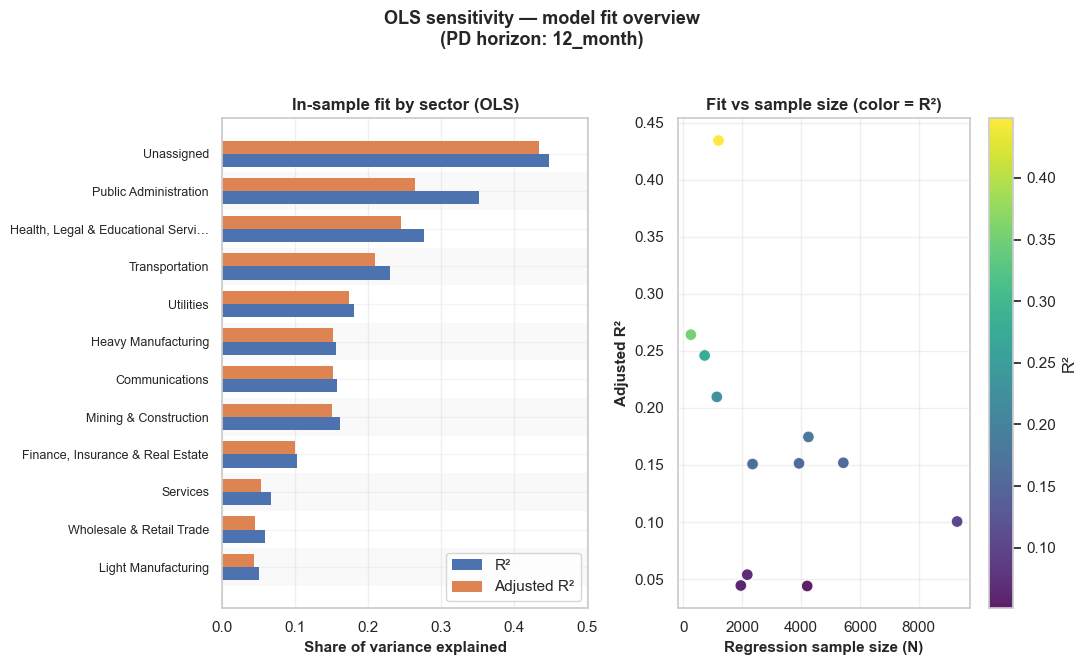

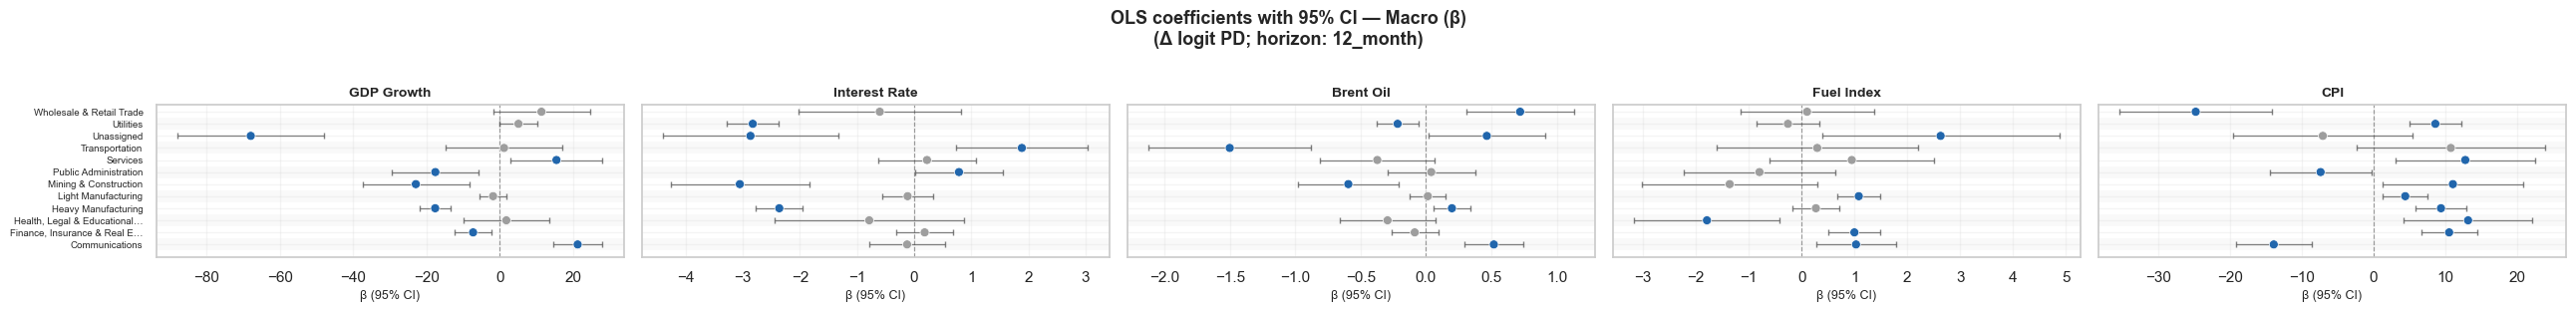

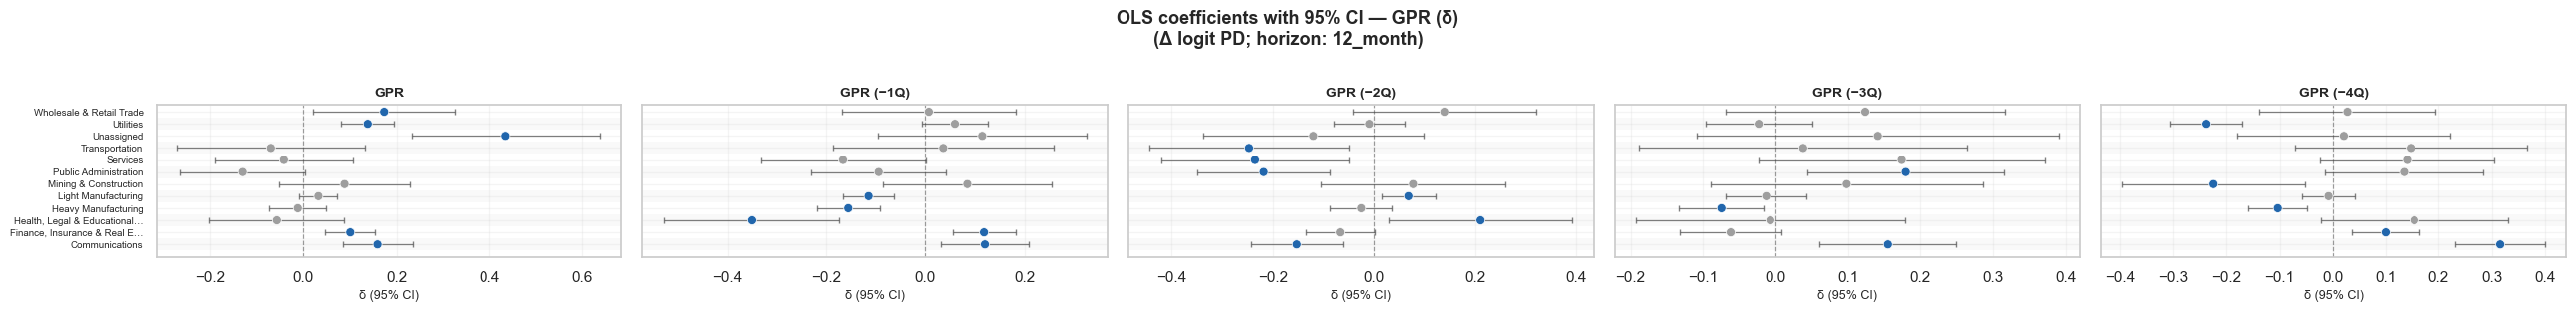

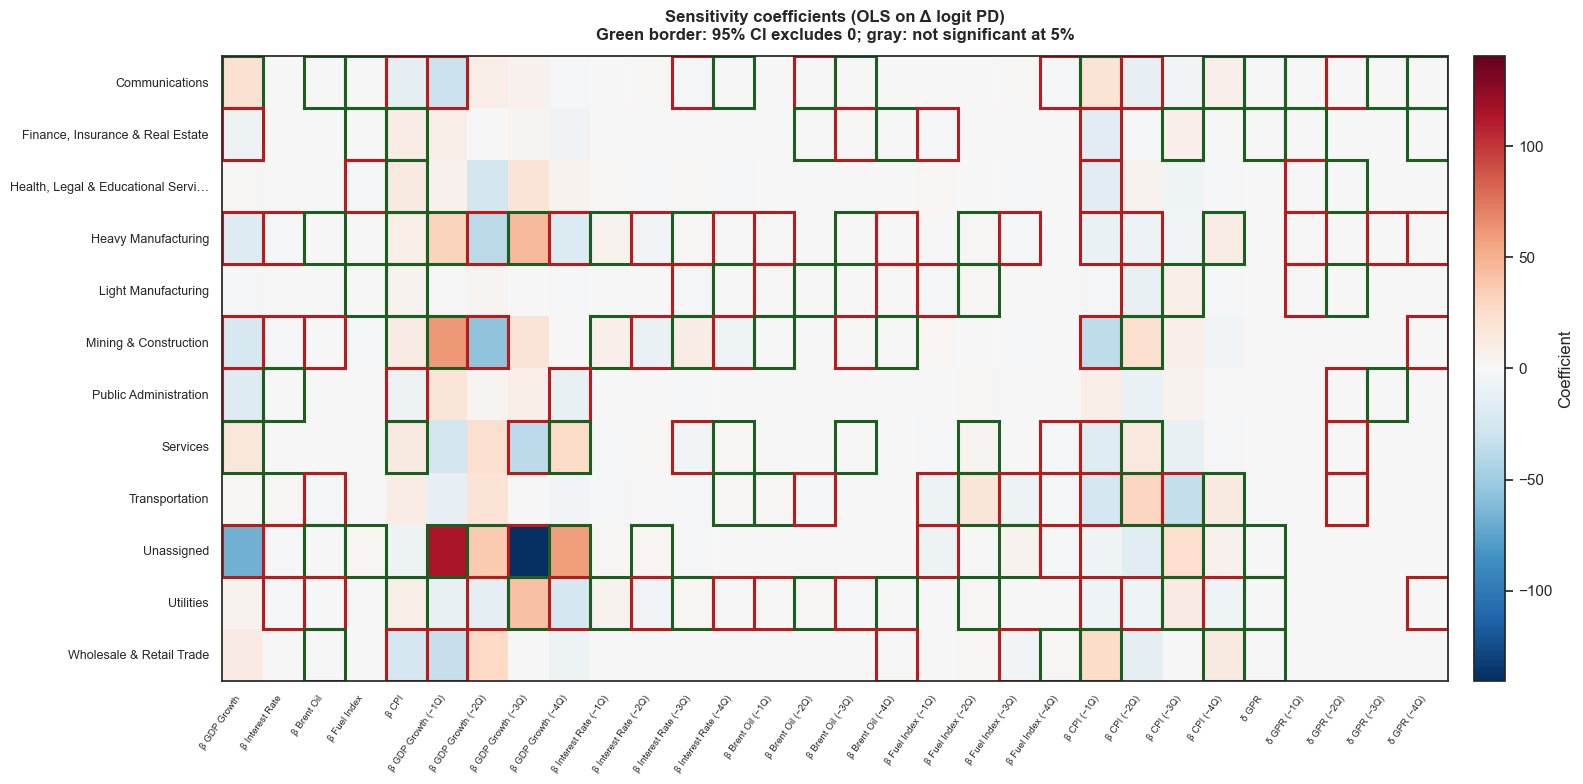

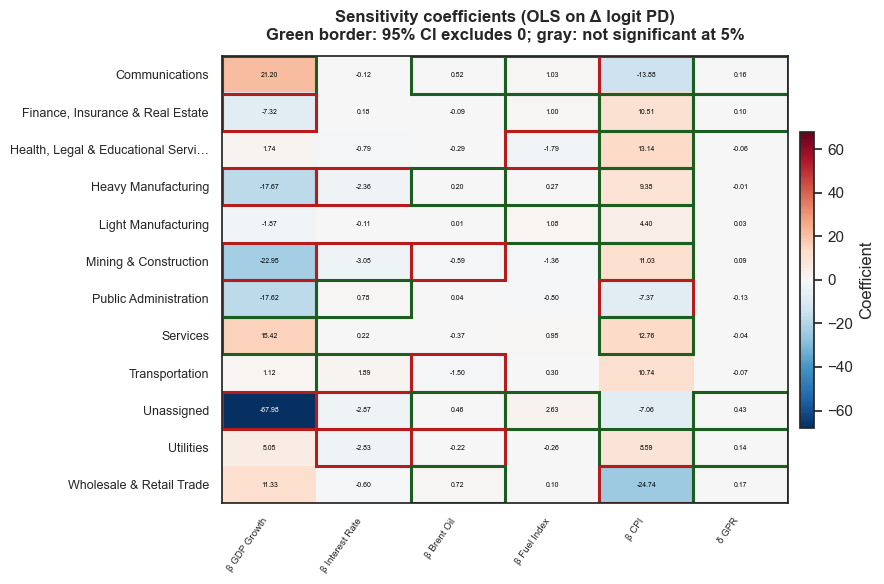

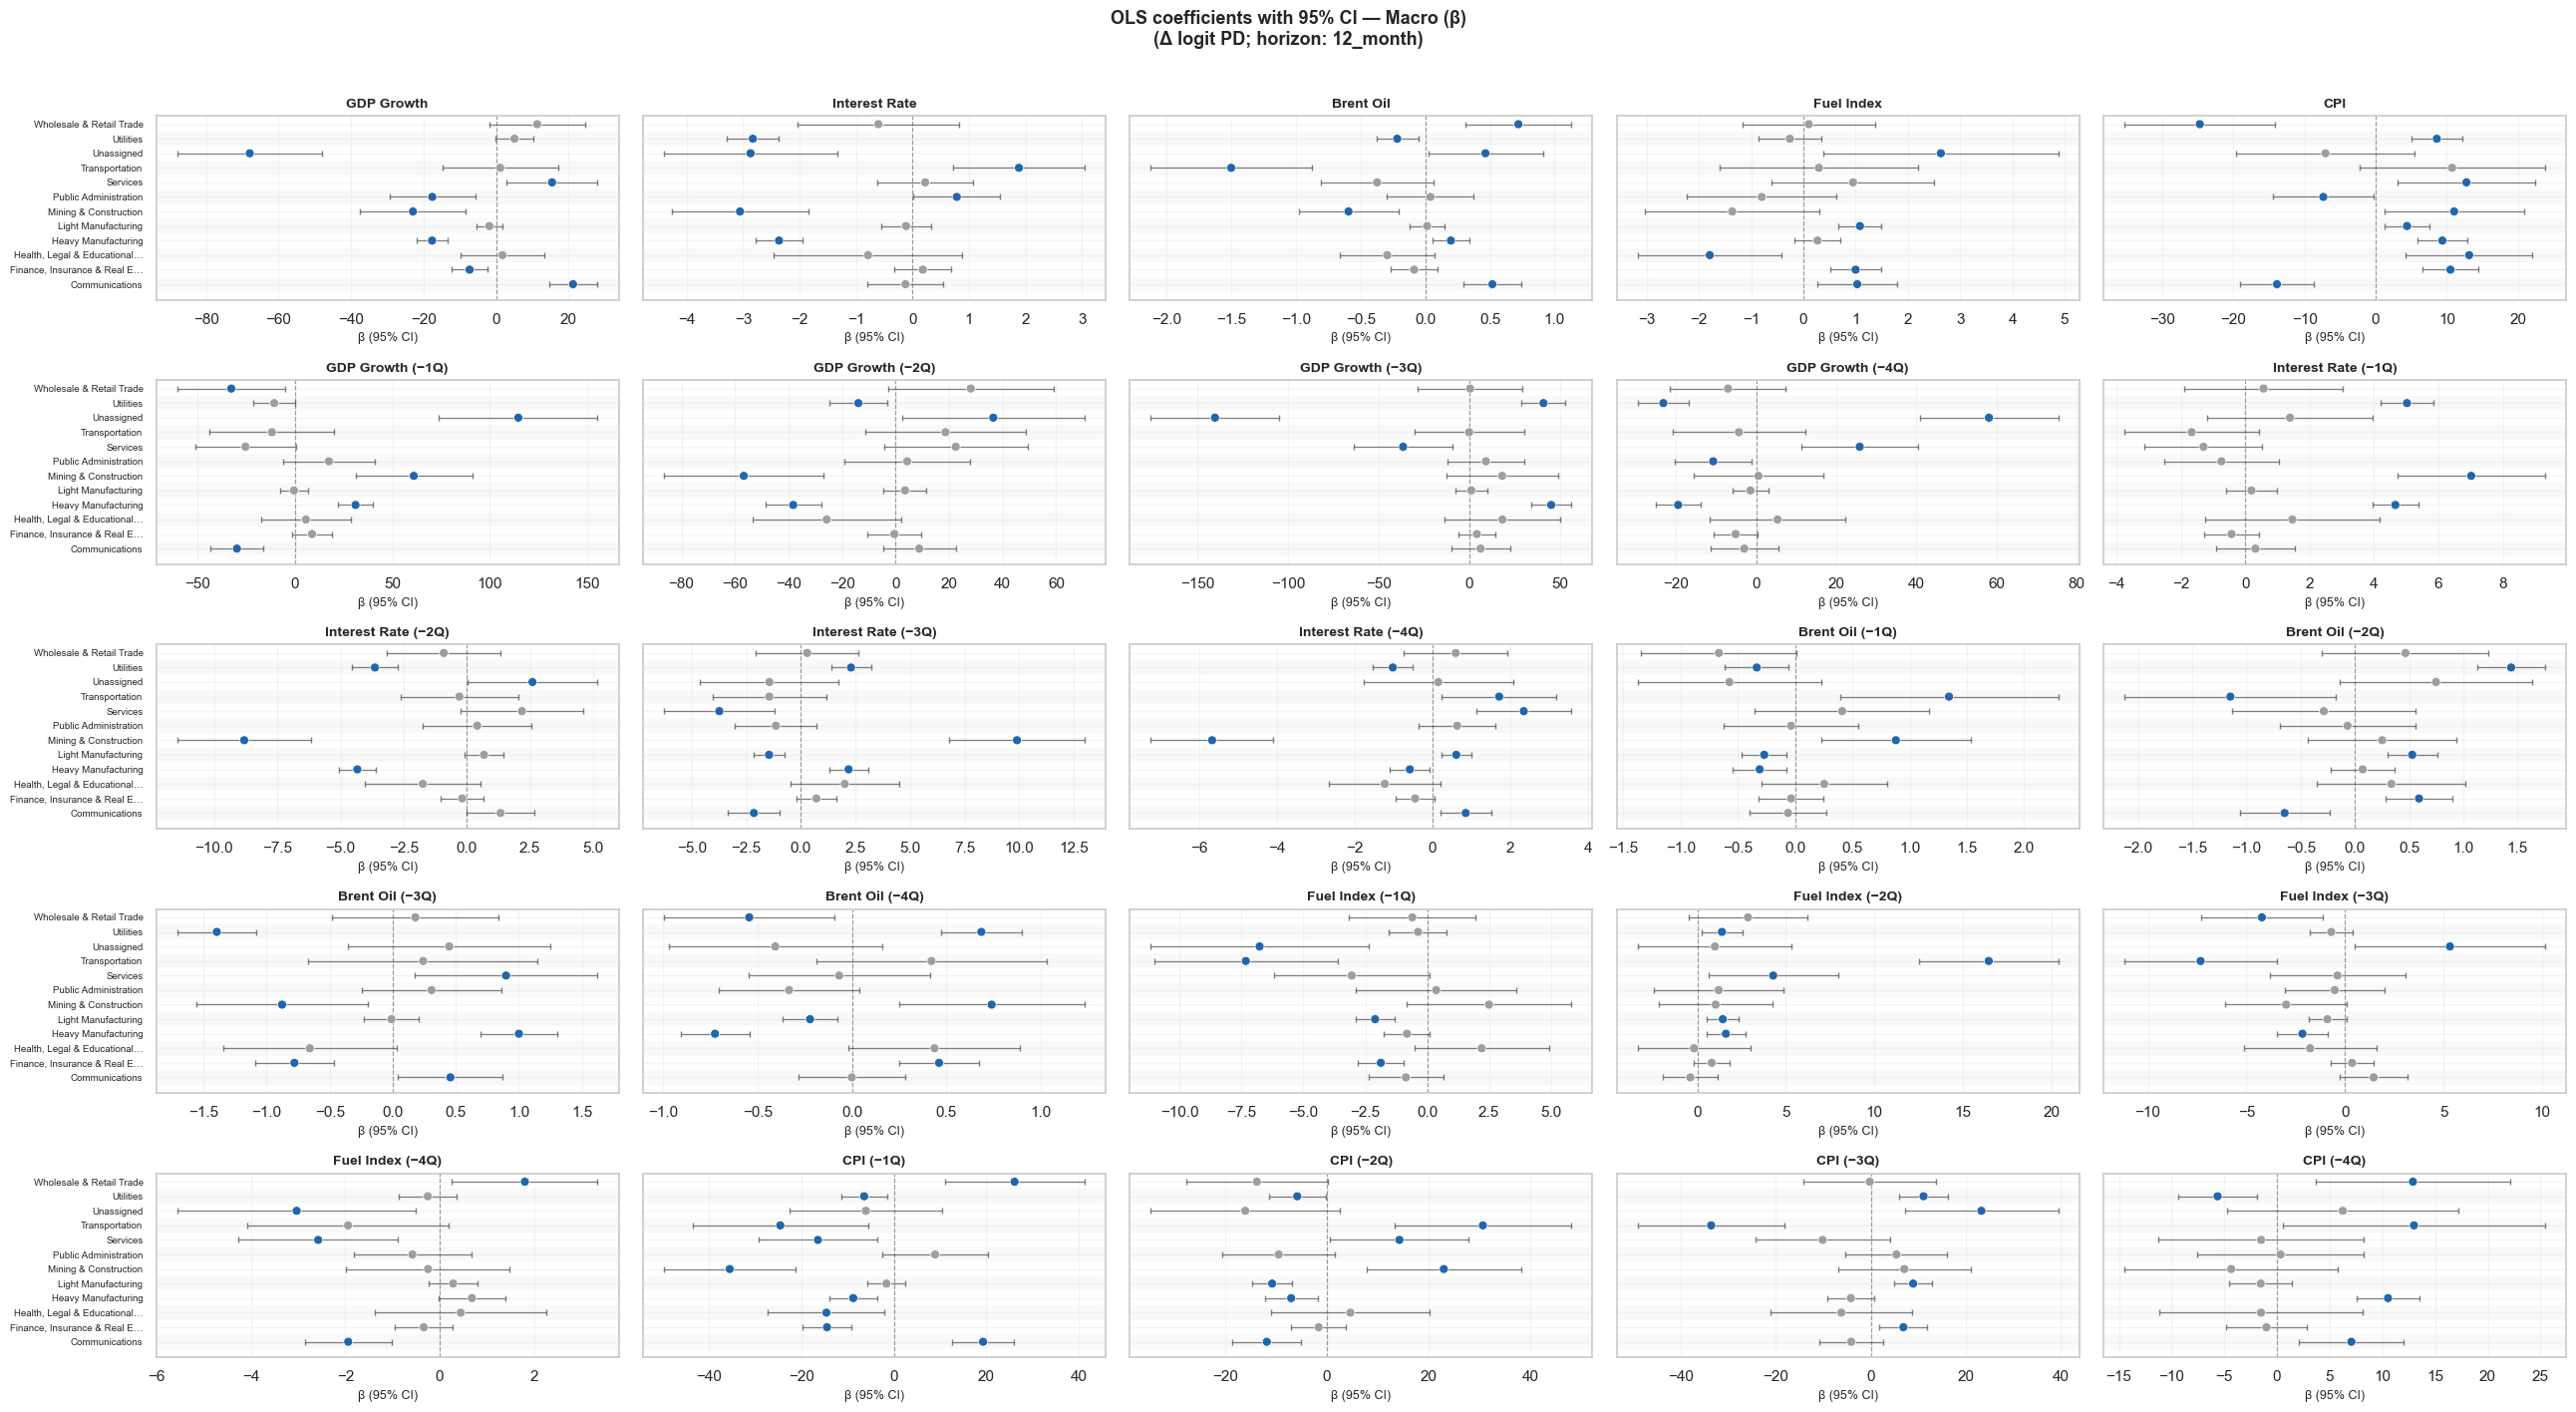

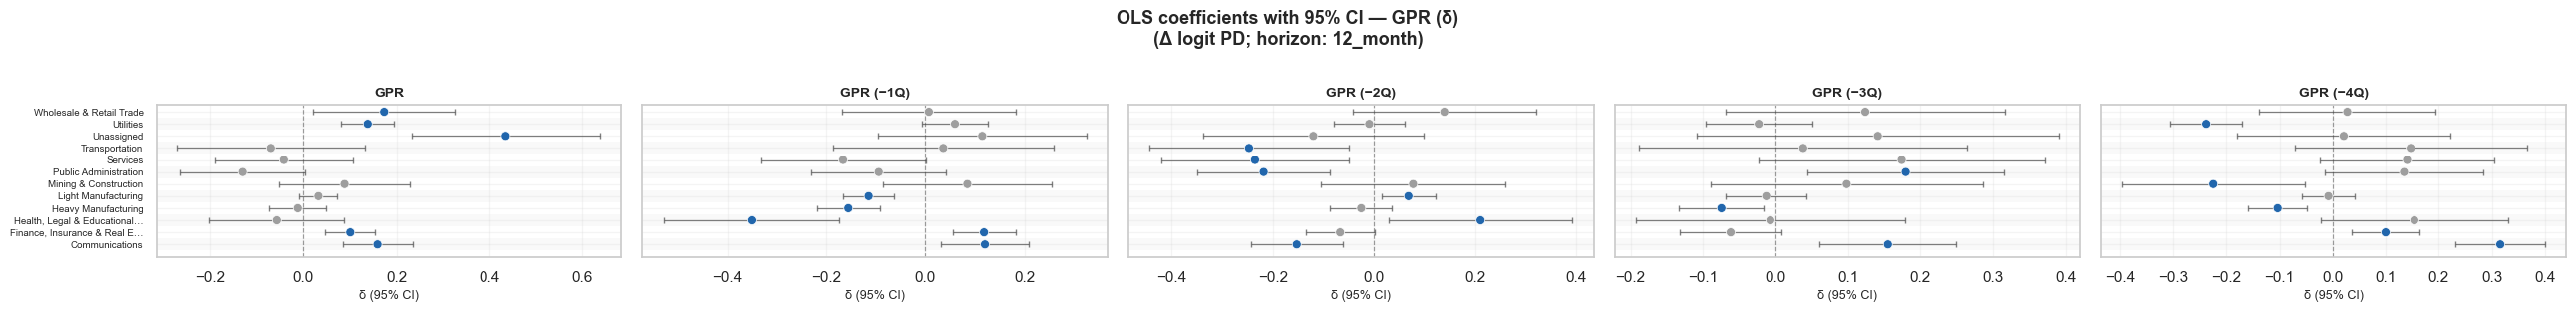

In [11]:
# Clear sensitivity visualisations for the thesis (re-run the sensitivity + export cells if columns are missing)
_pd_h = config.PD_MATURITY_COLS[0]

plots.plot_sensitivity_model_fit(df_sensitivities, pd_horizon=_pd_h, figsize=(11, 6.5))

# Contemporaneous macro — easy to read in the main text
plots.plot_sensitivity_coefficient_forest(
    df_sensitivities, config.MACRO_COLS, kind="macro", pd_horizon=_pd_h
)

# All GPR terms (current + lags)
plots.plot_sensitivity_coefficient_forest(
    df_sensitivities, config.ALL_GPR_COLS, kind="gpr", pd_horizon=_pd_h
)

# Full lag structure: pattern across all sectors (appendix / large slide; cell values omitted if >18 predictors)
plots.plot_sensitivity_significance_heatmap(
    df_sensitivities, config.ALL_MACRO_COLS, config.ALL_GPR_COLS, pd_horizon=_pd_h
)

# Compact: current-quarter macro + GPR only
plots.plot_sensitivity_significance_heatmap(
    df_sensitivities, config.MACRO_COLS, config.GPR_COLS, pd_horizon=_pd_h, figsize=(9, 6)
)

# OLS forests — every regressor in the full lagged specification (macro figure, then GPR figure)
plots.plot_sensitivity_forests_all_predictors(
    df_sensitivities,
    config.ALL_MACRO_COLS,
    config.ALL_GPR_COLS,
    pd_horizon=_pd_h,
)

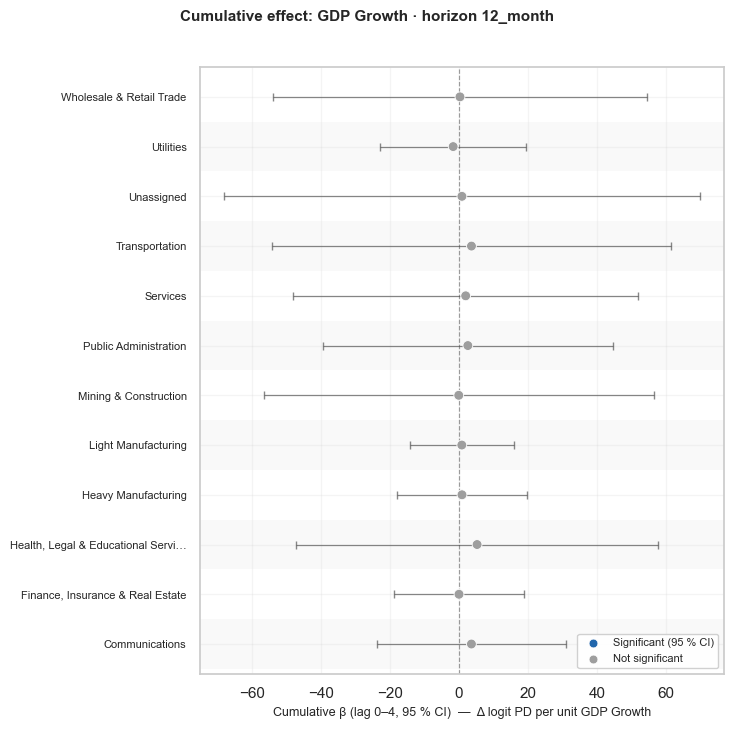

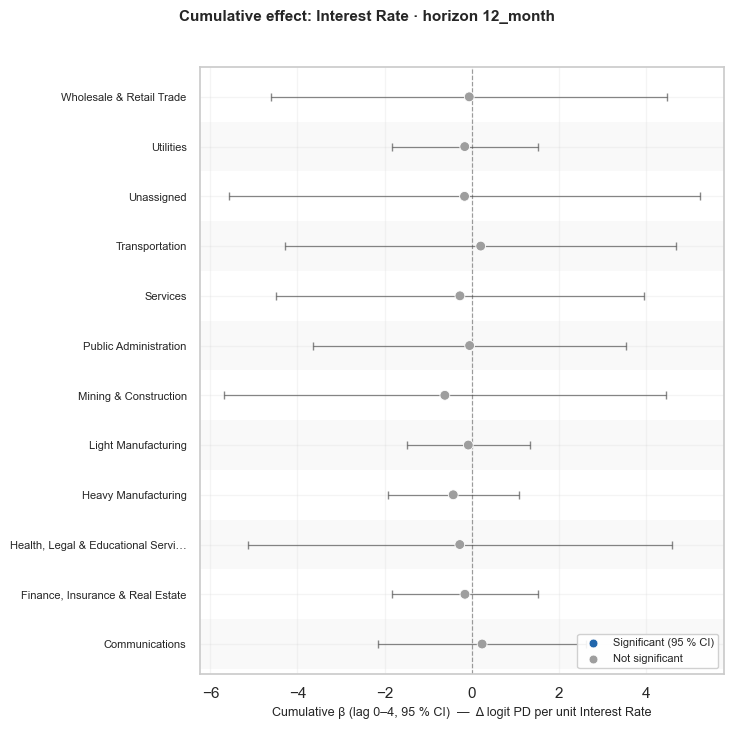

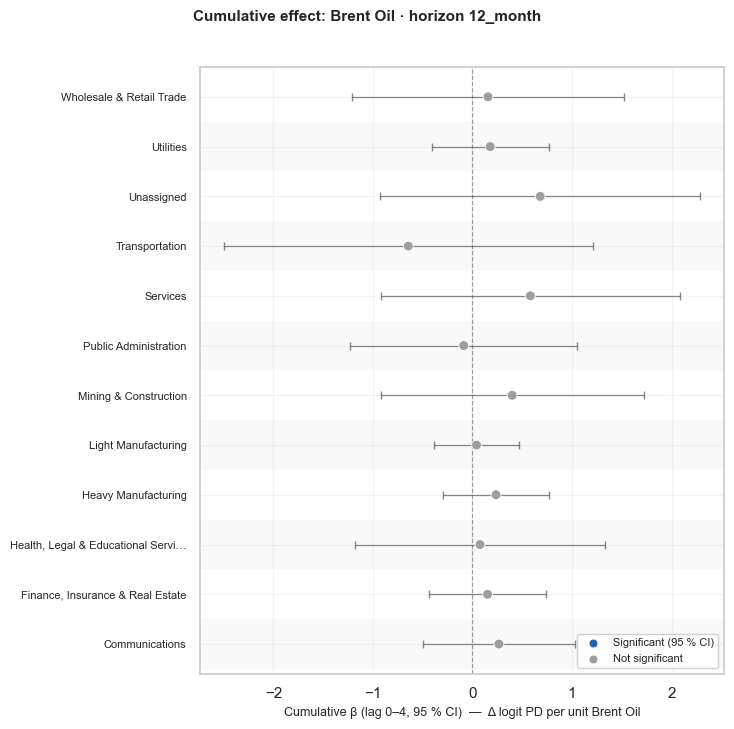

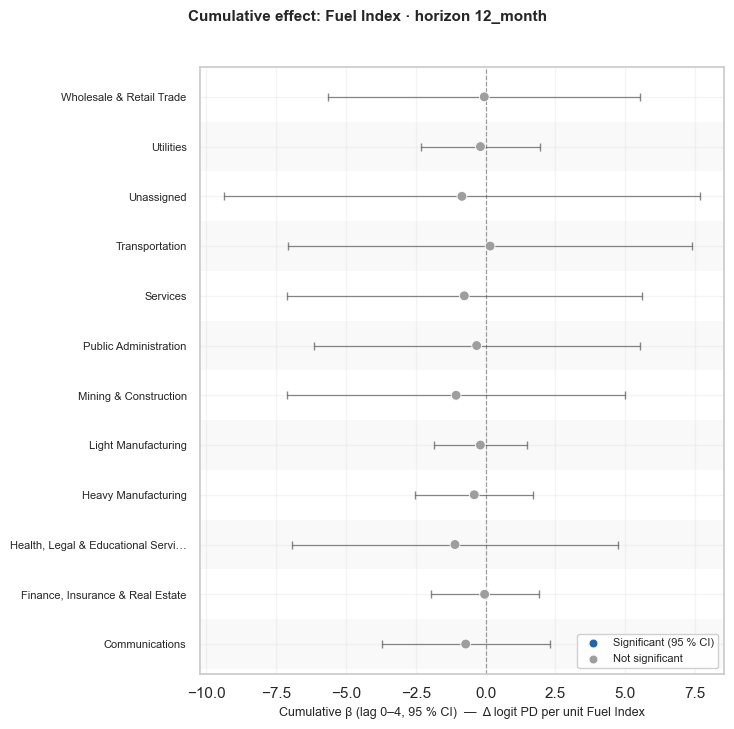

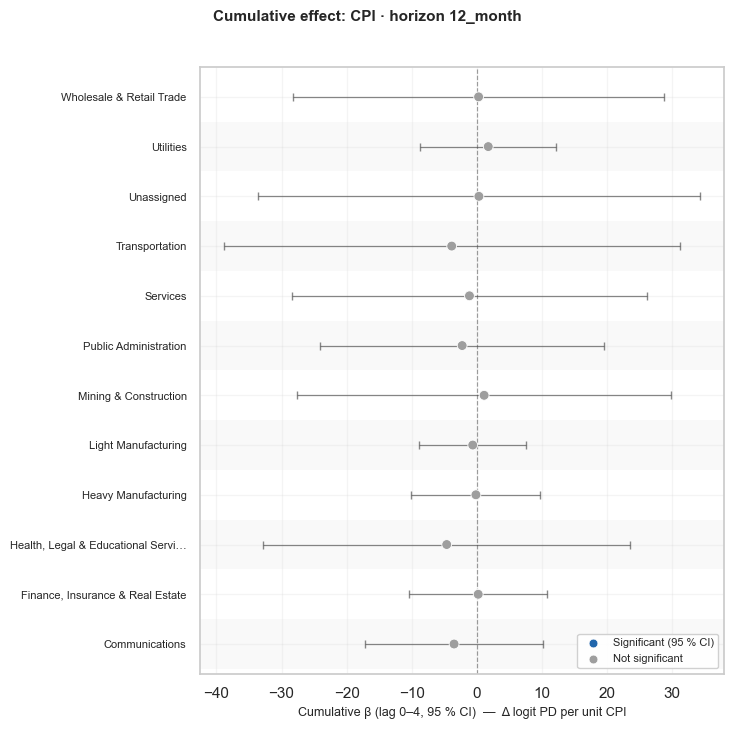

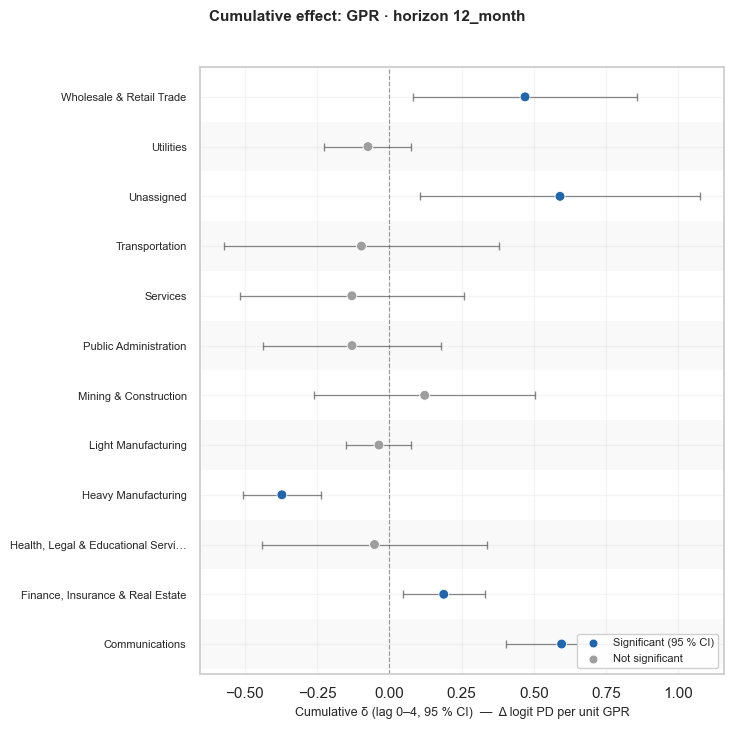

In [12]:
# Cumulative (summed) OLS coefficients — one thesis figure per variable
# β_total = β_lag0 + β_lag1 + β_lag2 + β_lag3 + β_lag4  (same for δ / GPR)
# 95 % CI propagated in quadrature (independent-lags approximation)

_pd_h = config.PD_MATURITY_COLS[0]

plots.plot_cumulative_coefficient_forest(
    df_sensitivities,
    base_cols=config.MACRO_COLS,
    all_cols=config.ALL_MACRO_COLS,
    kind='macro',
    pd_horizon=_pd_h,
)

plots.plot_cumulative_coefficient_forest(
    df_sensitivities,
    base_cols=config.GPR_COLS,
    all_cols=config.ALL_GPR_COLS,
    kind='gpr',
    pd_horizon=_pd_h,
)

In [13]:
# Elastic-Net feature selection (ElasticNetCV over alpha × l1_ratio grid)
df_lasso, lasso_selected_features = lasso.run_lasso_feature_selection(
    df_final_cleaned,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=True,
)

feature_freq_df = lasso.print_lasso_summary(df_lasso, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)
comparison_full = lasso.compare_ols_lasso(df_sensitivities, df_lasso, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)
lasso.export_lasso_outputs(df_lasso, comparison_full)
lasso.print_feature_recommendations(feature_freq_df, comparison_full)

# Bootstrap stability (B=200 per sector — takes a few minutes)
df_lasso = lasso.run_bootstrap_stability(
    df_final_cleaned, df_lasso,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    n_bootstrap=200,
    verbose=True,
)

# Regularization paths (used for the path plot below)
path_data = lasso.compute_regularization_paths(
    df_final_cleaned, df_lasso,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=False,
)

ELASTIC-NET FEATURE SELECTION

Searching over alpha × l1_ratio grid (5-fold CV).
l1_ratio grid: [0.1, 0.5, 0.7, 0.9, 0.95, 1.0]
l1_ratio=1.0 → pure LASSO  |  <1.0 → Elastic-Net (handles correlated lags)

Sector: Communications (n=5268)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



12_month:
  α=0.407685  l1_ratio=0.10
  R²=0.077  R²_adj=0.074  R²_cv=-0.015
  Features selected: 16/30
  Selected features:
    Interest_Rate                 :   0.0217
    CPI                           :   0.0051
    Interest_Rate_lag1            :   0.0222
    Interest_Rate_lag2            :   0.0139
    Interest_Rate_lag3            :   0.0075
    Interest_Rate_lag4            :   0.0059
    Brent_Oil_lag2                :  -0.0433
    Brent_Oil_lag3                :  -0.0217
    Fuel_Index_lag4               :  -0.0146
    CPI_lag1                      :   0.0013
    CPI_lag3                      :   0.0009
    CPI_lag4                      :   0.0054
    GPR_Global                    :   0.1251
    GPR_Global_lag1               :   0.0489
    GPR_Global_lag3               :   0.0089
    GPR_Global_lag4               :   0.0449

Sector: Utilities (n=5694)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



12_month:
  α=0.064058  l1_ratio=0.70
  R²=0.084  R²_adj=0.083  R²_cv=-0.095
  Features selected: 4/30
  Selected features:
    Brent_Oil                     :  -0.0279
    Fuel_Index_lag4               :  -0.0345
    GPR_Global                    :   0.2010
    GPR_Global_lag4               :  -0.1054

Sector: Mining & Construction (n=3104)


...


12_month:
  α=0.014867  l1_ratio=1.00
  R²=0.346  R²_adj=0.340  R²_cv=-0.340
  Features selected: 11/30
  Selected features:
    Interest_Rate                 :  -0.7818
    Brent_Oil                     :  -0.0647
    Fuel_Index                    :  -0.5239
    GDP_Growth_lag4               :   0.1856
    Interest_Rate_lag2            :   1.1647
    Brent_Oil_lag3                :   0.2514
    Fuel_Index_lag4               :   0.2846
    GPR_Global                    :   0.1394
    GPR_Global_lag2               :  -0.0473
    GPR_Global_lag3               :   0.1197
    GPR_Global_lag4               :  -0.1227

Sector: Wholesale & Retail Trade (n=2831)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



12_month:
  α=1.565766  l1_ratio=0.10
  R²=0.000  R²_adj=0.000  R²_cv=-0.113
  Features selected: 0/30
  No features selected (all shrunk to zero)

Sector: Transportation (n=1444)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



12_month:
  α=0.001896  l1_ratio=1.00
  R²=0.195  R²_adj=0.181  R²_cv=-0.038
  Features selected: 19/30
  Selected features:
    Interest_Rate                 :   0.9015
    Brent_Oil                     :  -0.8939
    GDP_Growth_lag2               :   2.1725
    Interest_Rate_lag2            :  -1.2497
    Interest_Rate_lag3            :  -0.0022
    Interest_Rate_lag4            :   0.4809
    Brent_Oil_lag1                :   0.4882
    Brent_Oil_lag2                :  -0.5417
    Brent_Oil_lag3                :  -0.2166
    Brent_Oil_lag4                :   0.5906
    Fuel_Index_lag1               :  -4.0160
    Fuel_Index_lag2               :   9.6874
    Fuel_Index_lag3               :  -2.4943
    Fuel_Index_lag4               :  -2.8333
    CPI_lag3                      :  -2.3472
    GPR_Global                    :   0.0343
    GPR_Global_lag1               :  -0.0405
    GPR_Global_lag2               :  -0.1059
    GPR_Global_lag3               :   0.0126

ELASTIC-NET RESULT

Plotting 10 sectors (top 20 by observation count)


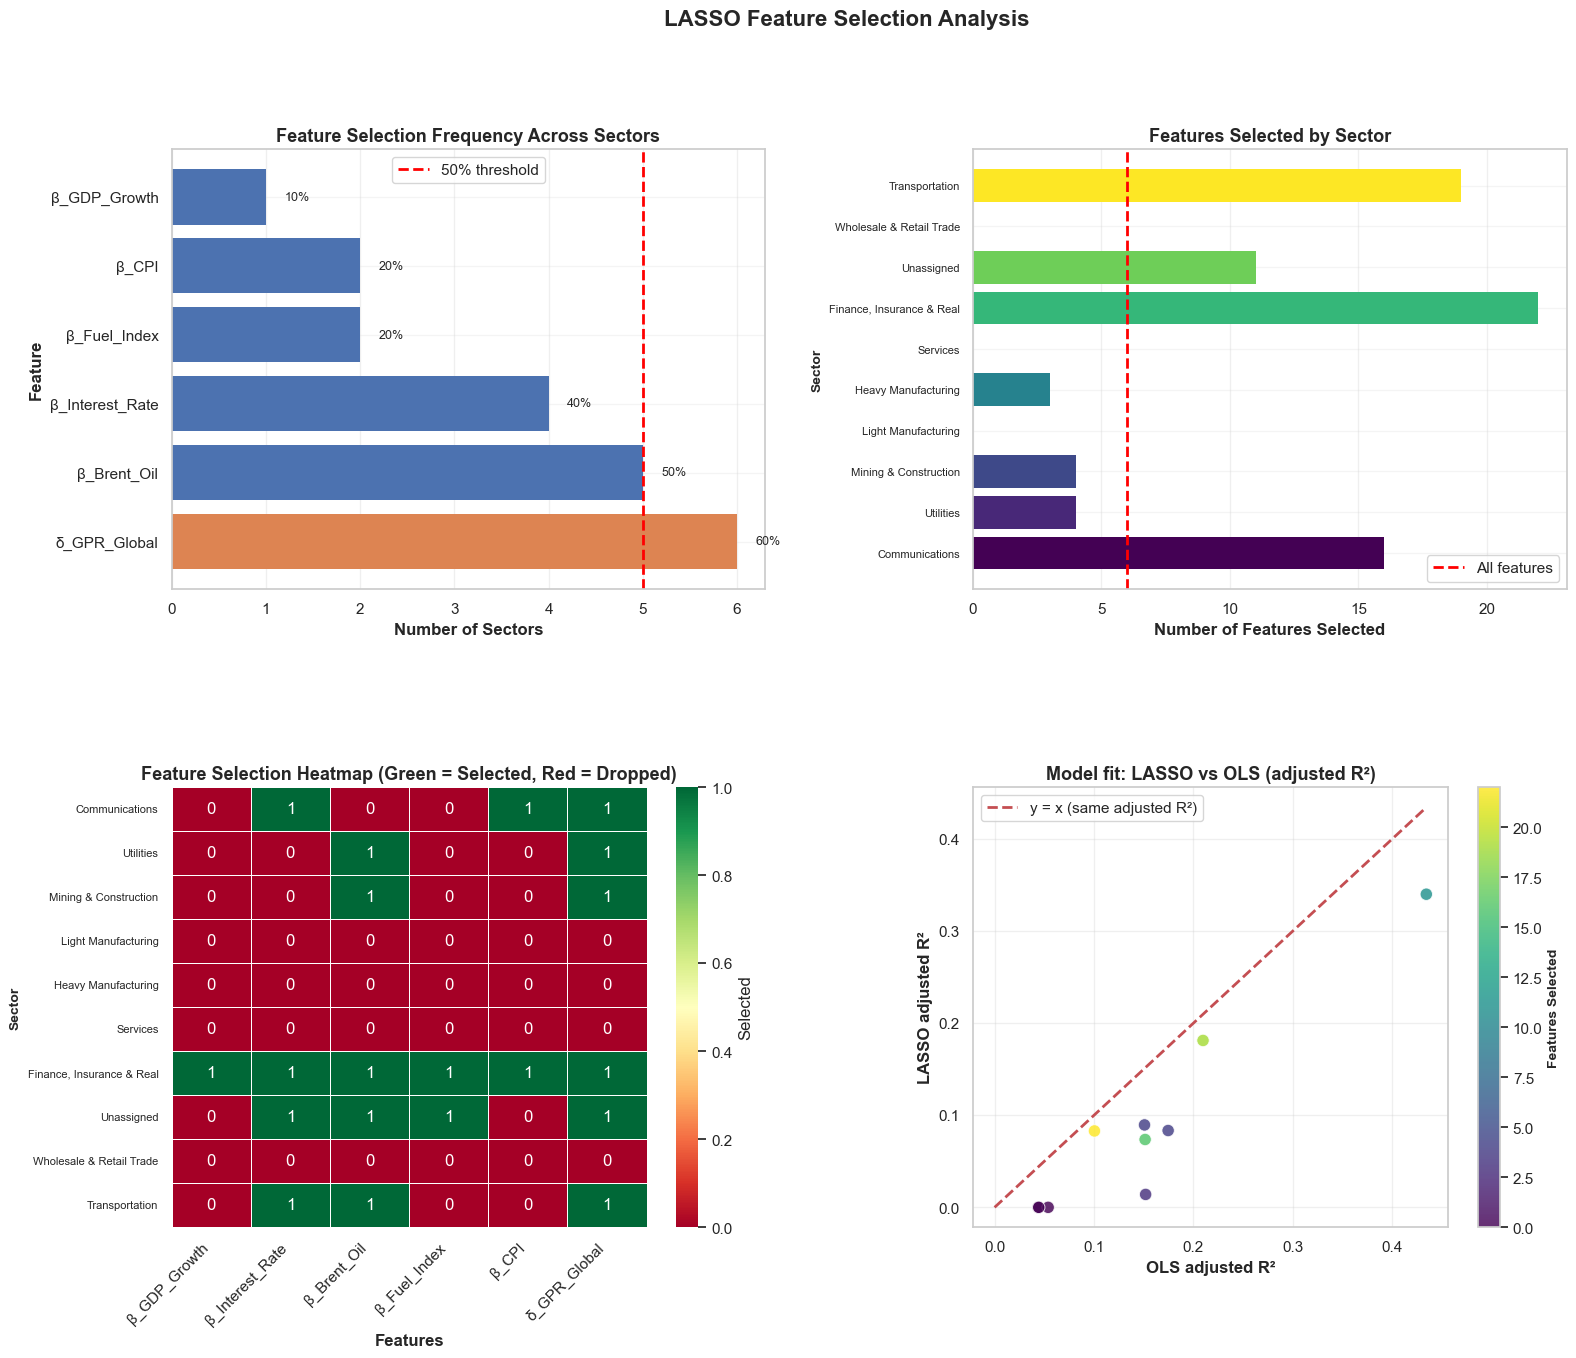

path_data is empty — run lasso.compute_regularization_paths() first.


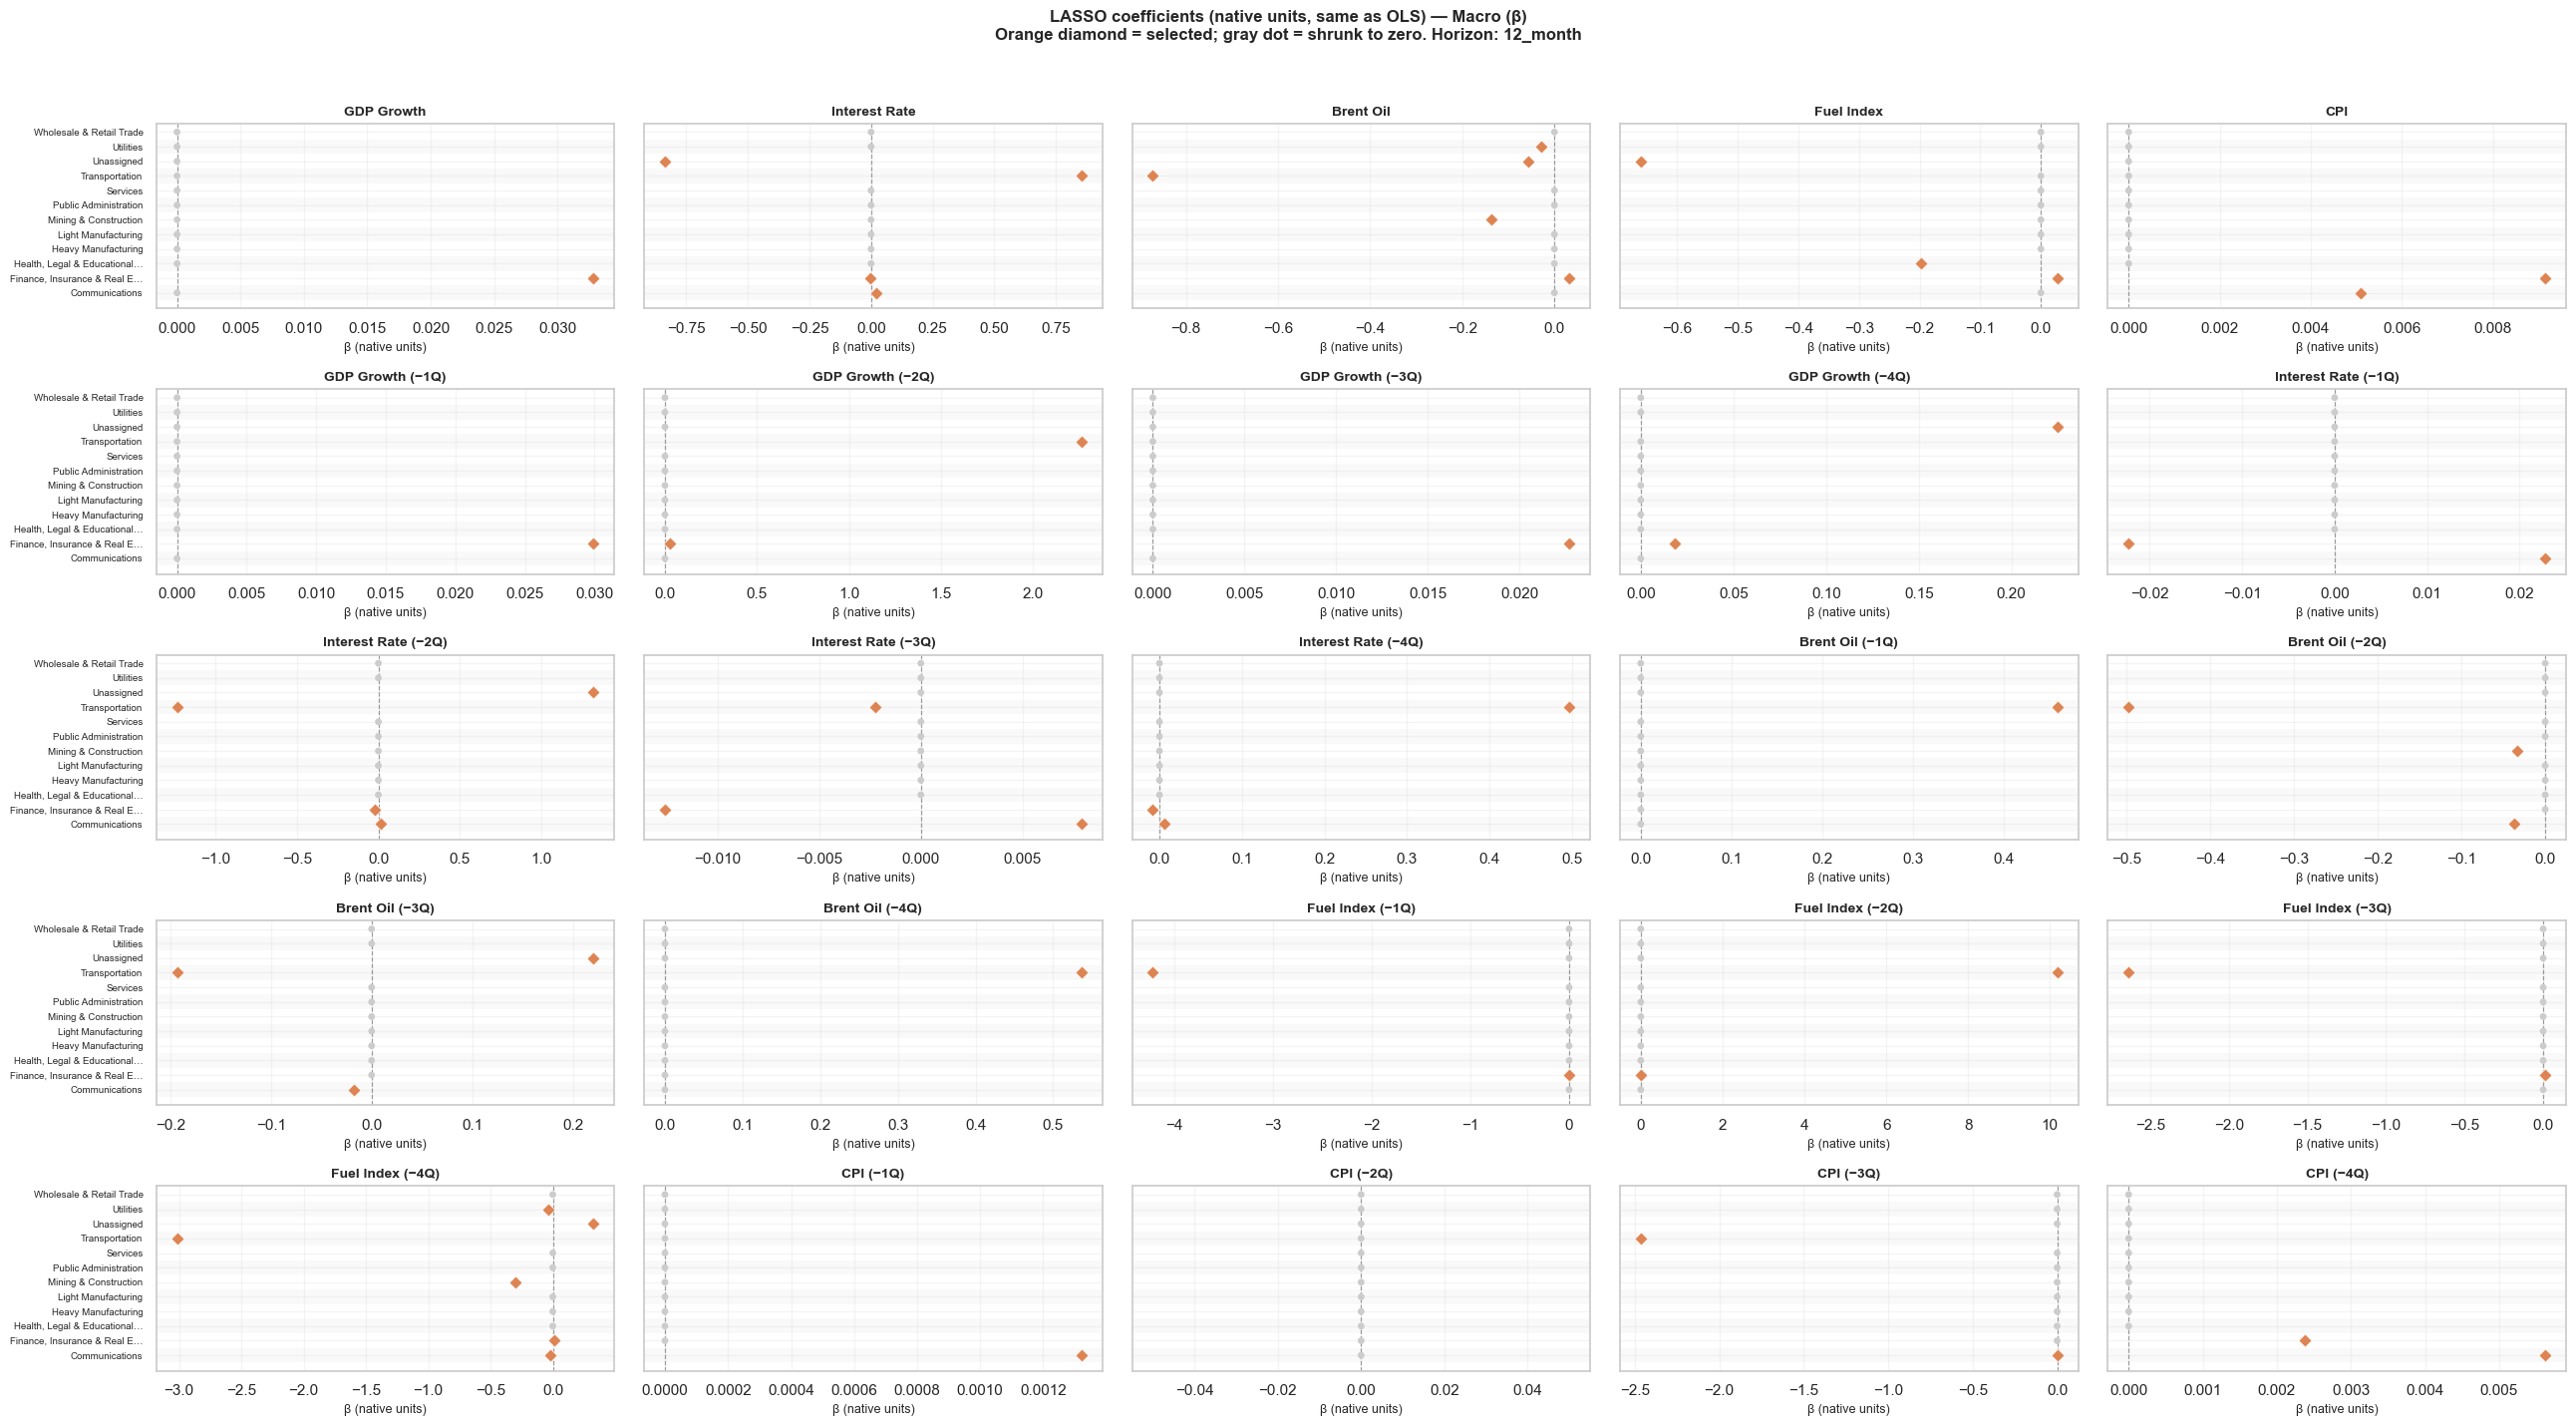

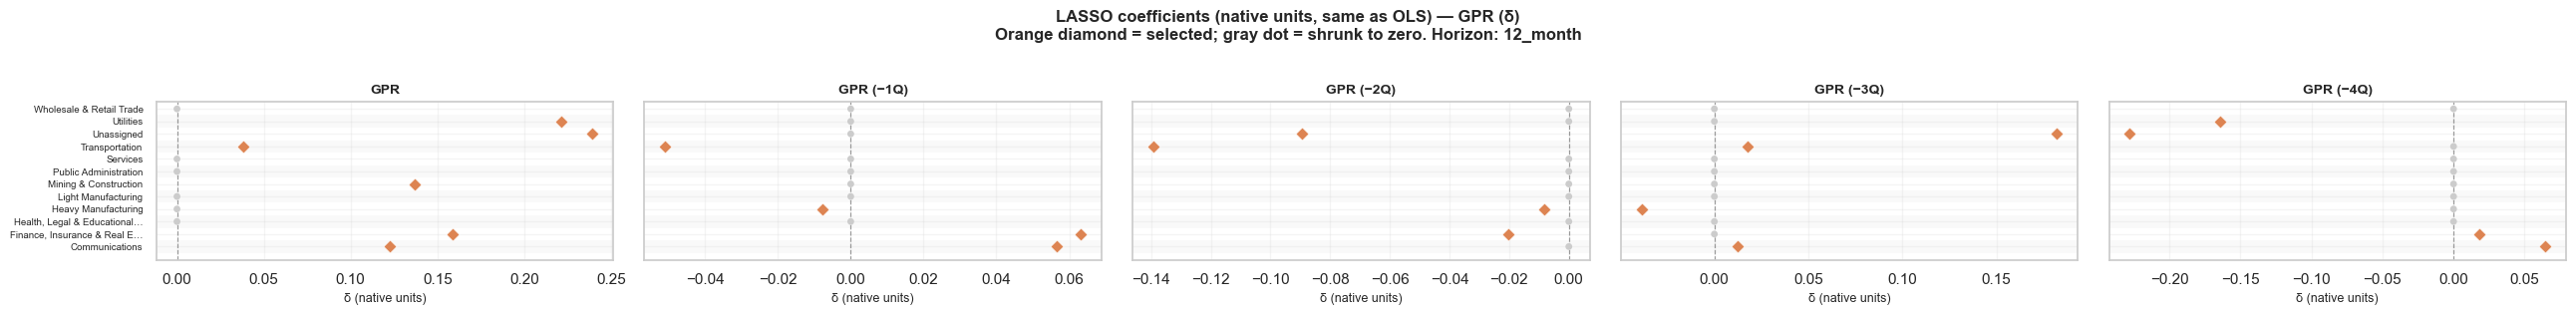

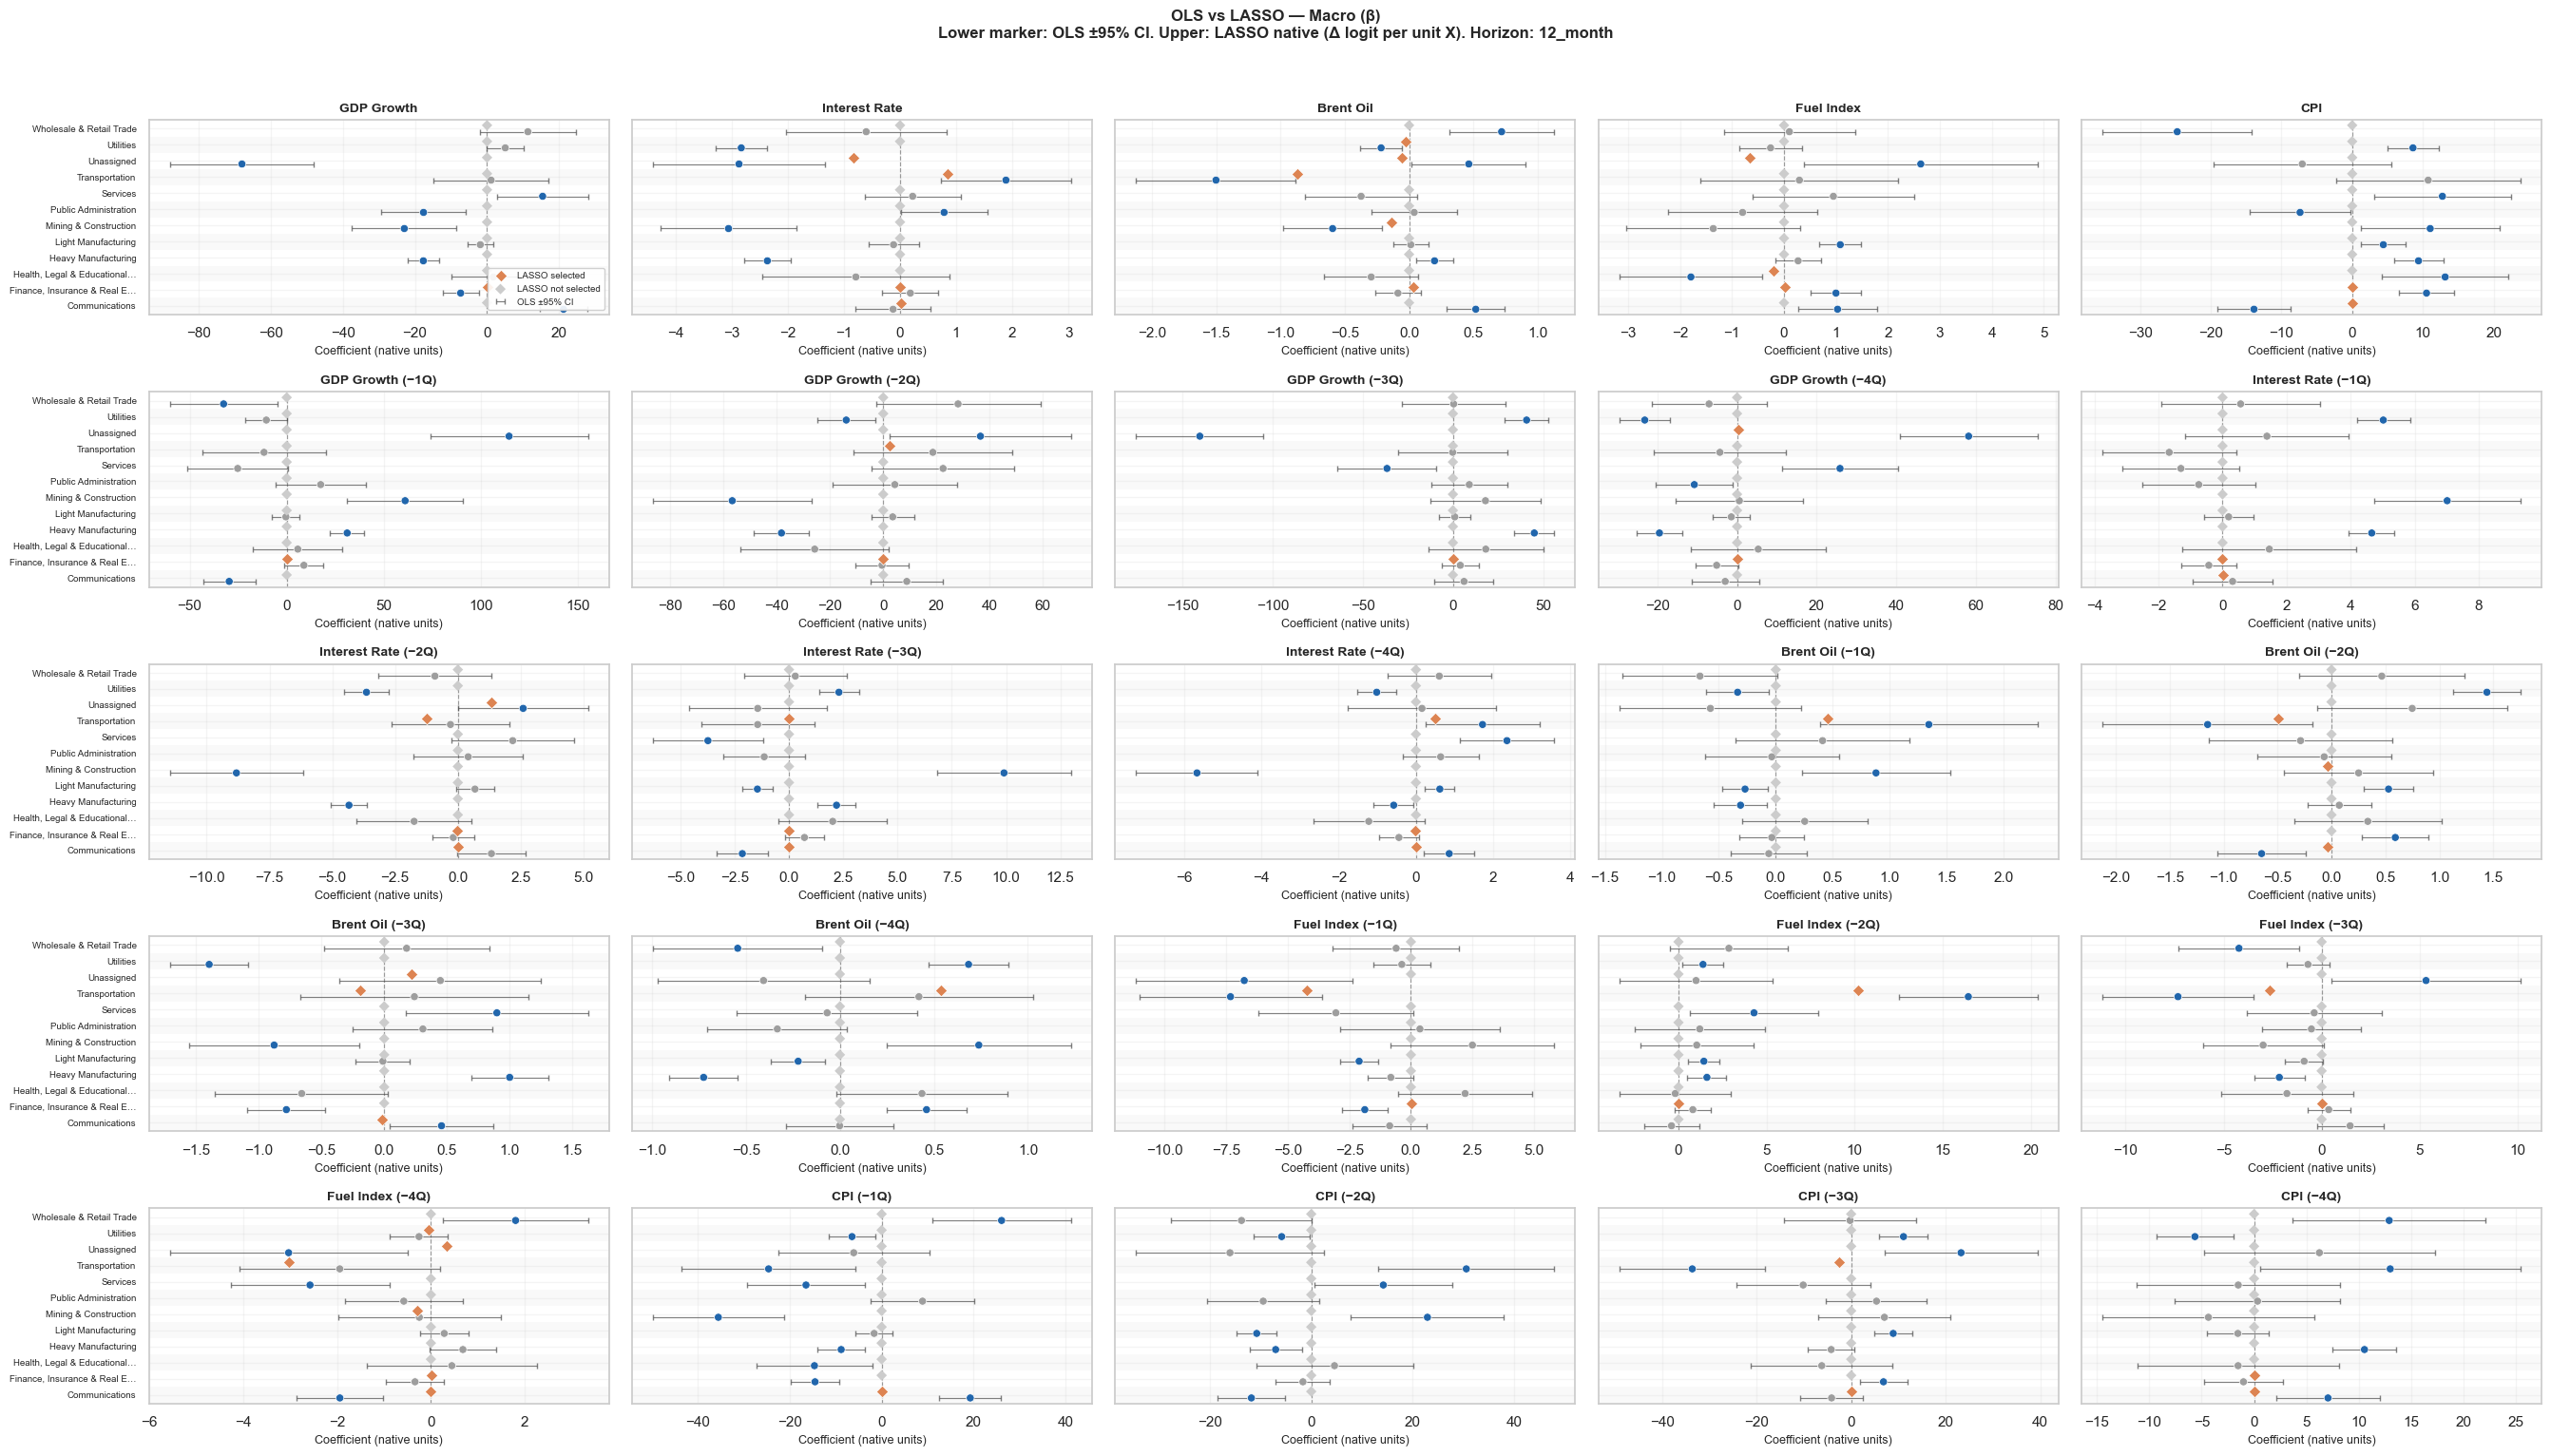

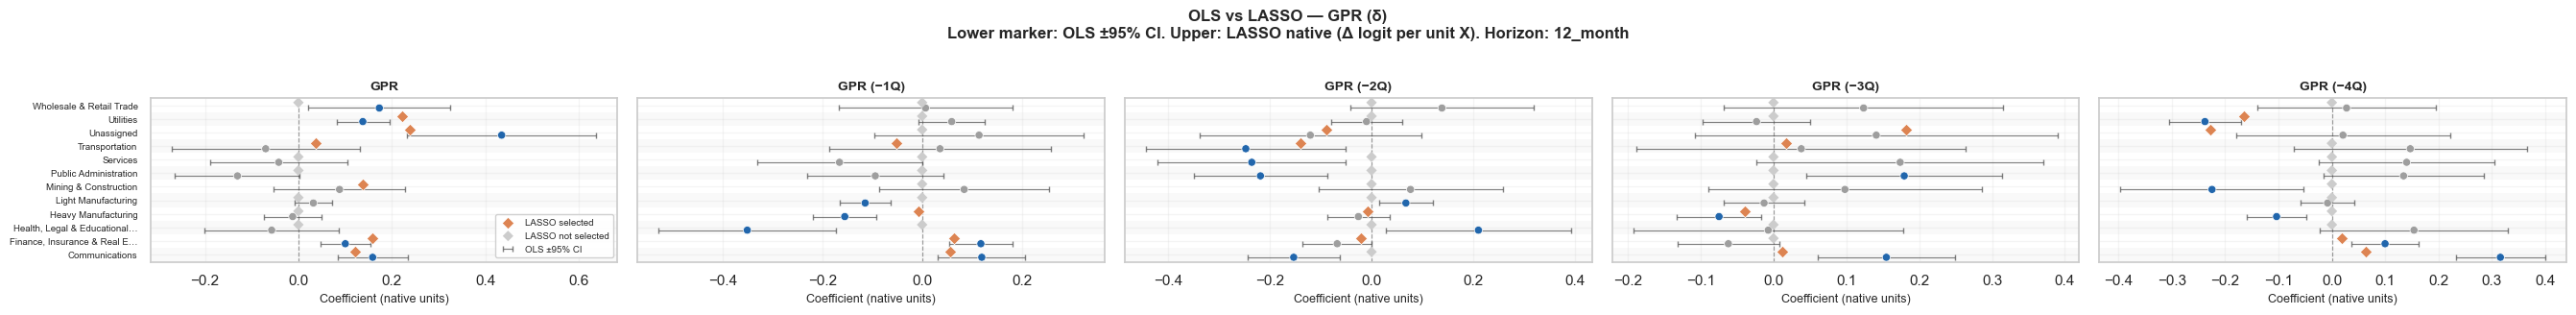

In [14]:
# LASSO / Elastic-Net visualizations
_pd_h = config.PD_MATURITY_COLS[0]

# 1. Summary: feature frequency, sector feature counts, selection heatmap, R² scatter
plots.plot_lasso_summary(df_lasso, feature_freq_df, config.MACRO_COLS, config.GPR_COLS, df_sensitivities)

# 2. Regularization paths — how coefficients evolve as penalty increases (top 4 sectors)
plots.plot_regularization_paths(path_data, config.ALL_MACRO_COLS, config.ALL_GPR_COLS, top_n=4)

# 4. Elastic-Net coefficient forests (native units, same scale as OLS)
plots.plot_lasso_forests_all_predictors(
    df_lasso, config.ALL_MACRO_COLS, config.ALL_GPR_COLS, pd_horizon=_pd_h
)

# 5. OLS vs Elastic-Net side-by-side comparison forests
plots.plot_ols_lasso_forest_comparison_all(
    df_sensitivities, df_lasso,
    config.ALL_MACRO_COLS, config.ALL_GPR_COLS,
    pd_horizon=_pd_h,
)

/Users/gustavjerresand/RST2.0-Modellen/pd_pipeline/plots.py:1676: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


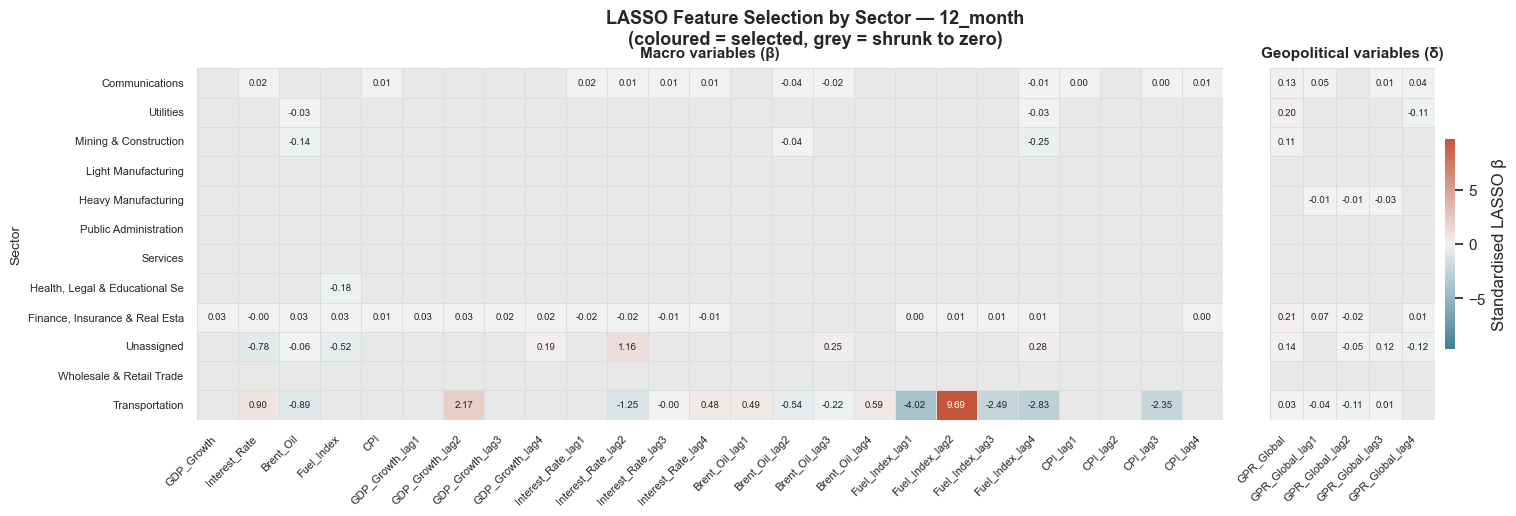

In [15]:
# Heatmap: LASSO betas for macro & geopolitical variables by sector
# Coloured cells = variable selected (non-zero beta); grey = shrunk to zero.
# Colour encodes the standardised coefficient magnitude and sign.
plots.plot_lasso_beta_heatmap(
    df_lasso,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    pd_horizon=config.PD_MATURITY_COLS[0],
)

### Model Selection: Which Sensitivity Specification to Use in the Optimisation?

Three distinct regression specifications are evaluated and compared on both in-sample and out-of-sample (cross-validated) fit:

| # | Specification | Predictors | Description |
|---|---------------|-----------|-------------|
| **M1** | **Full-lag OLS** | 30 | OLS with current + 4 lags as *separate* predictors for each of the 5 macro and 1 GPR variable |
| **M2** | **Cumulative OLS** | 6 | OLS where each macro/GPR variable is replaced by its **cumulative sum across lags** (X_t + X_{t-1} + … + X_{t-4}) before fitting — one coefficient per driver |
| **M3** | **Elastic-Net** | CV-selected (≤30) | Regularised regression on the full 30-predictor set; jointly selects alpha and L1-ratio by cross-validation |

**Why M2 is a separate model from M1.** In M1, each lag gets its own free coefficient — the fit is flexible but uses 30 degrees of freedom. In M2, a single coefficient is estimated against the *pre-summed* variable, imposing the constraint that all lags contribute equally. This is a stronger prior about how macro shocks accumulate, but it may fit the data worse.

**Selection criterion.** In-sample R² favours models with more parameters (always M1 ≥ M2, M3). Adjusted R² partially corrects for this, but the most relevant metric for a downstream optimisation is *cross-validated* R² (5-fold), which directly measures how well each model would generalise to unseen data. Sensitivity coefficients that overfit will produce unreliable stress-test trajectories.

**Economic interpretation for the optimisation.** The stress scenario applies a sustained level shift to each macro driver. The coefficient from M2 (β_cumul) directly represents the total PD response to a one-unit permanent shift — which is exactly what is needed. For M1, the equivalent total effect must be reconstructed as β₀ + β₁ + … + β₄.

In [16]:

# ── Three-model comparison: M1 (full-lag OLS) | M2 (cumulative OLS) | M3 (EN) ─
#
# M1: OLS with current + 4 lags as separate predictors  → 30 predictors
# M2: OLS where each variable is replaced by its cumulative sum → 6 predictors
# M3: Elastic-Net on the same 30-predictor set (CV-regularised)
#
# We compute 5-fold CV R² for all three so the comparison is on equal footing.

import statsmodels.api as sm
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

_CV_FOLDS = 5
_pd_h = config.PD_MATURITY_COLS[0]


def _build_cumulative_X(df, macro_cols, gpr_cols):
    """Replace each base variable with its cumulative sum across lags.

    For each base variable (e.g. GDP_Growth), sum the contemporaneous value
    and all lagged versions present in the DataFrame into a single column.
    Returns a DataFrame with one column per base variable.
    """
    base_macro = config.MACRO_COLS   # contemporaneous names only
    base_gpr   = config.GPR_COLS

    cumul = {}
    for base in base_macro:
        lag_cols = [c for c in macro_cols if c == base or c.startswith(f'{base}_lag')]
        cumul[f'{base}_cumul'] = df[lag_cols].sum(axis=1)
    for base in base_gpr:
        lag_cols = [c for c in gpr_cols if c == base or c.startswith(f'{base}_lag')]
        cumul[f'{base}_cumul'] = df[lag_cols].sum(axis=1)
    return pd.DataFrame(cumul, index=df.index)


def _fit_sector_ols(y, X_raw, n_preds=None):
    """OLS fit; returns (r2, r2_adj, aic, bic) or Nones on failure."""
    X = sm.add_constant(X_raw)
    try:
        m = sm.OLS(y, X).fit()
        k = n_preds if n_preds is not None else (X.shape[1] - 1)
        n = len(y)
        r2_adj = 1 - (1 - m.rsquared) * (n - 1) / (n - k - 1) if n > k + 1 else float('nan')
        return m.rsquared, r2_adj, m.aic, m.bic
    except Exception:
        return float('nan'), float('nan'), float('nan'), float('nan')


def _cv_r2(X_raw, y, estimator, cv=5):
    """5-fold CV R² on StandardScaler-transformed X."""
    X_sc = StandardScaler().fit_transform(X_raw)
    scores = cross_val_score(estimator, X_sc, y, cv=cv, scoring='r2')
    return float(scores.mean())


def _cv_rmse(X_raw, y, estimator, cv=5):
    """5-fold CV RMSE on StandardScaler-transformed X."""
    X_sc = StandardScaler().fit_transform(X_raw)
    scores = cross_val_score(estimator, X_sc, y, cv=cv, scoring='neg_root_mean_squared_error')
    return float(-scores.mean())


print("Fitting M2 (cumulative OLS) and computing CV R² for all three models …")

m1_rows, m2_rows = [], []

for sector in df_final_cleaned[config.SECTOR_COL].unique():
    sdf = df_final_cleaned[df_final_cleaned[config.SECTOR_COL] == sector].copy()
    sdf['delta_logit'] = (
        sensitivity.calculate_logit(sdf[_pd_h])
        - sensitivity.calculate_logit(sdf[config.PDZERO_COL])
    )
    y_full = sdf['delta_logit']

    # ── M1 predictors (30 columns) ────────────────────────────────────────────
    X1 = pd.concat([sdf[config.ALL_MACRO_COLS], sdf[config.ALL_GPR_COLS]], axis=1)
    ok1 = ~(y_full.isna() | X1.isna().any(axis=1))
    y1, X1 = y_full[ok1], X1[ok1]

    # ── M2 predictors (6 cumulative columns) ─────────────────────────────────
    X2 = _build_cumulative_X(sdf, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)
    ok2 = ~(y_full.isna() | X2.isna().any(axis=1))
    y2, X2 = y_full[ok2], X2[ok2]

    if len(y1) >= 20:
        r2_1, r2adj_1, aic_1, bic_1 = _fit_sector_ols(y1, X1, n_preds=X1.shape[1])
        cv_1    = _cv_r2(X1.values, y1.values, LinearRegression(), cv=_CV_FOLDS)
        rmse_1  = _cv_rmse(X1.values, y1.values, LinearRegression(), cv=_CV_FOLDS)
        m1_rows.append({'Sector': sector, 'M1_R2': r2_1, 'M1_R2adj': r2adj_1,
                         'M1_AIC': aic_1, 'M1_BIC': bic_1, 'M1_R2cv': cv_1,
                         'M1_RMSEcv': rmse_1,
                         'M1_N_pred': X1.shape[1], 'N_obs': len(y1)})

    if len(y2) >= 20:
        r2_2, r2adj_2, aic_2, bic_2 = _fit_sector_ols(y2, X2, n_preds=X2.shape[1])
        cv_2    = _cv_r2(X2.values, y2.values, LinearRegression(), cv=_CV_FOLDS)
        rmse_2  = _cv_rmse(X2.values, y2.values, LinearRegression(), cv=_CV_FOLDS)
        m2_rows.append({'Sector': sector, 'M2_R2': r2_2, 'M2_R2adj': r2adj_2,
                         'M2_AIC': aic_2, 'M2_BIC': bic_2, 'M2_R2cv': cv_2,
                         'M2_RMSEcv': rmse_2,
                         'M2_N_pred': X2.shape[1]})

df_m1  = pd.DataFrame(m1_rows)
df_m2  = pd.DataFrame(m2_rows)

# M3: pull from existing df_lasso (already has EN CV R²)
df_m3 = (
    df_lasso[df_lasso['PD_Horizon'] == _pd_h]
    [['Sector', 'R_squared', 'R_squared_adj', 'R_squared_cv', 'N_features_selected']]
    .copy()
    .rename(columns={'R_squared': 'M3_R2', 'R_squared_adj': 'M3_R2adj',
                     'R_squared_cv': 'M3_R2cv', 'RMSE_cv': 'M3_RMSEcv',
                     'N_features_selected': 'M3_N_feat'})
)

comp = df_m1.merge(df_m2, on='Sector').merge(df_m3, on='Sector', how='left')

# ── Print comparison table ────────────────────────────────────────────────────
_fmt3 = lambda x: f'{x:.3f}' if pd.notna(x) else '—'
_fmt1 = lambda x: f'{x:.1f}' if pd.notna(x) else '—'

tbl = comp[['Sector', 'N_obs',
            'M1_R2', 'M1_R2adj', 'M1_R2cv', 'M1_RMSEcv', 'M1_AIC',
            'M2_R2', 'M2_R2adj', 'M2_R2cv', 'M2_RMSEcv', 'M2_AIC',
            'M3_R2', 'M3_R2adj', 'M3_R2cv', 'M3_RMSEcv', 'M3_N_feat']].copy()
tbl = tbl.rename(columns={
    'N_obs':      'N',
    'M1_R2':      'M1 R²',    'M1_R2adj': 'M1 Adj R²', 'M1_R2cv': 'M1 CV R²', 'M1_RMSEcv': 'M1 CV RMSE', 'M1_AIC': 'M1 AIC',
    'M2_R2':      'M2 R²',    'M2_R2adj': 'M2 Adj R²', 'M2_R2cv': 'M2 CV R²', 'M2_RMSEcv': 'M2 CV RMSE', 'M2_AIC': 'M2 AIC',
    'M3_R2':      'M3 R²',    'M3_R2adj': 'M3 Adj R²', 'M3_R2cv': 'M3 CV R²', 'M3_RMSEcv': 'M3 CV RMSE', 'M3_N_feat': 'M3 preds',
}).set_index('Sector')
tbl['N'] = tbl['N'].astype(int)
tbl['M3 preds'] = tbl['M3 preds'].astype(int)
for c in ['M1 R²', 'M1 Adj R²', 'M1 CV R²', 'M1 CV RMSE',
          'M2 R²', 'M2 Adj R²', 'M2 CV R²', 'M2 CV RMSE',
          'M3 R²', 'M3 Adj R²', 'M3 CV R²', 'M3 CV RMSE']:
    tbl[c] = tbl[c].map(_fmt3)
for c in ['M1 AIC', 'M2 AIC']:
    tbl[c] = tbl[c].map(_fmt1)

print(f"\nModel Comparison — PD Horizon: {_pd_h}")
print(f"  M1 = Full-lag OLS (30 preds)   M2 = Cumulative OLS (6 preds)   M3 = Elastic-Net (CV-selected preds)")
print("=" * 130)
print(tbl.to_string())
print("=" * 130)
print("\nCV R² (5-fold): negative values indicate worse-than-mean prediction.")


Computing 5-fold CV R² for OLS and Elastic-Net …

Model Comparison — PD Horizon: 12_month
                                         N  OLS preds OLS R² OLS Adj R² OLS CV R²  OLS AIC  EN preds  EN R² EN Adj R² EN CV R²
Sector                                                                                                                        
Communications                        3926         30  0.158      0.151    -0.162  11989.8        16  0.077     0.074   -0.015
Utilities                             4245         30  0.180      0.175    -0.339  11046.8         4  0.084     0.083   -0.095
Mining & Construction                 2347         30  0.162      0.151    -0.198   9154.4         4  0.091     0.089   -0.076
Light Manufacturing                   4204         30  0.051      0.044    -0.239   9083.1         0  0.000     0.000   -0.101
Heavy Manufacturing                   5433         30  0.157      0.152    -1.981  12375.0         3  0.015     0.014   -2.117
Public Administration

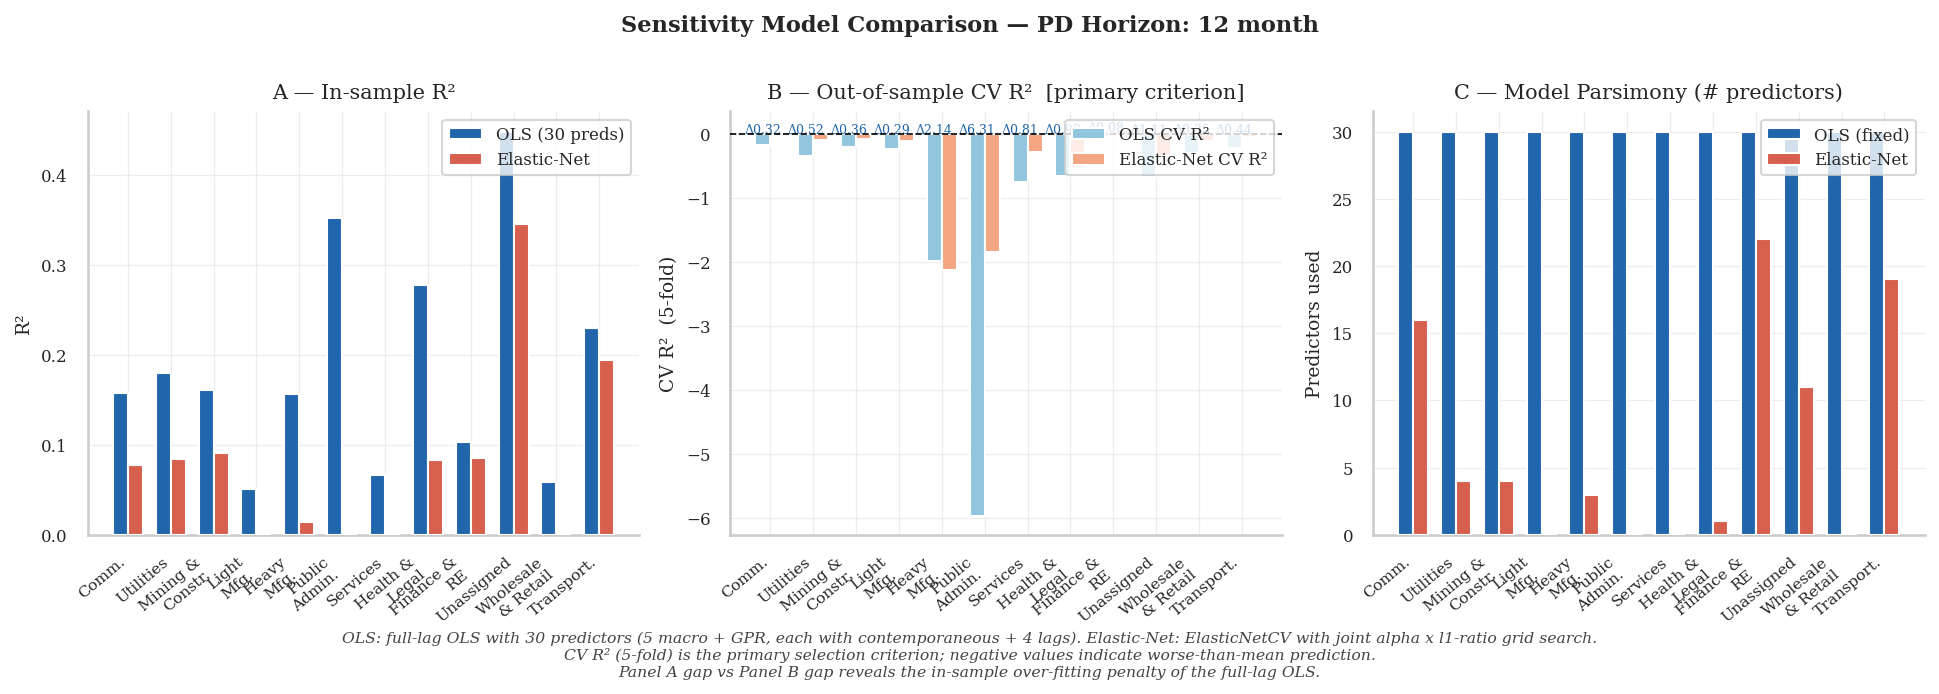

✓ Saved model_comparison.pdf / .png


In [17]:

# ── Thesis figure: Three-model comparison ─────────────────────────────────────
# Panel A: In-sample R²  (all three models)
# Panel B: Cross-validated R²  — primary selection criterion
# Panel C: AIC comparison  (M1 vs M2, penalises for extra predictors)
# Panel D: Predictors retained per model (parsimony)

import matplotlib.pyplot as plt
import numpy as np

_SECTOR_SHORT = {
    'Mining & Construction':                        'Mining &\nConstr.',
    'Light Manufacturing':                          'Light\nMfg.',
    'Heavy Manufacturing':                          'Heavy\nMfg.',
    'Transportation':                               'Transport.',
    'Communications':                               'Comm.',
    'Utilities':                                    'Utilities',
    'Wholesale & Retail Trade':                     'Wholesale\n& Retail',
    'Finance Insurance & Real Estate':              'Finance &\nRE',
    'Finance, Insurance & Real Estate':             'Finance &\nRE',
    'Services':                                     'Services',
    'Health Legal & Educational Services':          'Health &\nLegal',
    'Health, Legal & Educational Services':         'Health &\nLegal',
    'Public Administration':                        'Public\nAdmin.',
    'Unassigned':                                   'Unassigned',
}

_THESIS_RC = {
    'font.family':       'serif',
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'xtick.labelsize':   7.5,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linewidth':    0.6,
}

_C1 = '#2166AC'   # M1 full-lag OLS — steel blue
_C2 = '#4DAC26'   # M2 cumulative OLS — green
_C3 = '#D6604D'   # M3 Elastic-Net — red

_rows = comp.copy()
_rows['Sector_short'] = _rows['Sector'].map(_SECTOR_SHORT).fillna(_rows['Sector'])
x  = np.arange(len(_rows))
bw = 0.26   # three bars per group

with plt.rc_context(_THESIS_RC):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
    fig.suptitle(
        f'Sensitivity Model Comparison — PD Horizon: {_pd_h.replace("_", " ")}',
        fontweight='bold', y=1.01,
    )

    # ── Panel A: In-sample R² ─────────────────────────────────────────────────
    ax = axes[0]
    ax.bar(x - bw,   _rows['M1_R2'], bw, color=_C1, label='M1  Full-lag OLS',  zorder=3)
    ax.bar(x,        _rows['M2_R2'], bw, color=_C2, label='M2  Cumulative OLS', zorder=3)
    ax.bar(x + bw,   _rows['M3_R2'], bw, color=_C3, label='M3  Elastic-Net',   zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(_rows['Sector_short'], rotation=45, ha='right')
    ax.set_ylabel('R²')
    ax.set_title('A — In-sample R²')
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=7)

    # ── Panel B: CV R² ───────────────────────────────────────────────────────
    ax = axes[1]
    ax.bar(x - bw, _rows['M1_R2cv'], bw, color=_C1, alpha=0.75, label='M1 CV R²',  zorder=3)
    ax.bar(x,      _rows['M2_R2cv'], bw, color=_C2, alpha=0.75, label='M2 CV R²', zorder=3)
    ax.bar(x + bw, _rows['M3_R2cv'], bw, color=_C3, alpha=0.75, label='M3 CV R²',  zorder=3)
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--', zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(_rows['Sector_short'], rotation=45, ha='right')
    ax.set_ylabel('CV R²  (5-fold)')
    ax.set_title('B — Out-of-sample CV R²  [primary]')
    ax.legend(loc='upper right', framealpha=0.9, fontsize=7)

    # ── Panel C: AIC (lower = better; M3 has no AIC so omit) ─────────────────
    ax = axes[2]
    ax.bar(x - bw/2, _rows['M1_AIC'], bw, color=_C1, label='M1  Full-lag OLS',  zorder=3)
    ax.bar(x + bw/2, _rows['M2_AIC'], bw, color=_C2, label='M2  Cumulative OLS', zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(_rows['Sector_short'], rotation=45, ha='right')
    ax.set_ylabel('AIC  (lower is better)')
    ax.set_title('C — AIC: M1 vs M2\n(M3 regularised — no AIC)')
    ax.legend(loc='upper right', framealpha=0.9, fontsize=7)

    # ── Panel D: Predictors used ─────────────────────────────────────────────
    ax = axes[3]
    ax.bar(x - bw,  _rows['M1_N_pred'], bw, color=_C1, label='M1 (always 30)', zorder=3)
    ax.bar(x,       _rows['M2_N_pred'], bw, color=_C2, label='M2 (always 6)',  zorder=3)
    ax.bar(x + bw,  _rows['M3_N_feat'], bw, color=_C3, label='M3 (CV-selected)', zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(_rows['Sector_short'], rotation=45, ha='right')
    ax.set_ylabel('Predictors used')
    ax.set_title('D — Model Parsimony')
    ax.legend(loc='upper right', framealpha=0.9, fontsize=7)

    fig.text(
        0.5, -0.05,
        'M1: OLS with 30 separate lag predictors.  '
        'M2: OLS with 6 cumulative-sum predictors (X_t + X_{t-1} + ... + X_{t-4} per variable).  '
        'M3: ElasticNetCV on the 30-predictor set.\n'
        'Panel B (CV R²) and C (AIC) are the primary model-selection criteria. '
        'Negative CV R² indicates worse-than-mean out-of-sample prediction.',
        ha='center', fontsize=7.5, style='italic', color='#444444',
    )

    fig.tight_layout()
    plt.savefig('model_comparison.pdf', bbox_inches='tight', dpi=200)
    plt.savefig('model_comparison.png', bbox_inches='tight', dpi=200)
    plt.show()
    print("✓ Saved model_comparison.pdf / .png")


In [18]:

# ── Export comparison table to LaTeX and CSV ─────────────────────────────────

_export = comp[['Sector', 'N_obs',
                'M1_R2', 'M1_R2adj', 'M1_R2cv', 'M1_RMSEcv', 'M1_AIC',
                'M2_R2', 'M2_R2adj', 'M2_R2cv', 'M2_RMSEcv', 'M2_AIC',
                'M3_R2', 'M3_R2adj', 'M3_R2cv', 'M3_RMSEcv', 'M3_N_feat']].copy()
_export = _export.rename(columns={
    'N_obs':       'N',
    'M1_R2':       'M1 R2',    'M1_R2adj': 'M1 AdjR2', 'M1_R2cv': 'M1 CVR2', 'M1_RMSEcv': 'M1 CVRMSE', 'M1_AIC': 'M1 AIC',
    'M2_R2':       'M2 R2',    'M2_R2adj': 'M2 AdjR2', 'M2_R2cv': 'M2 CVR2', 'M2_RMSEcv': 'M2 CVRMSE', 'M2_AIC': 'M2 AIC',
    'M3_R2':       'M3 R2',    'M3_R2adj': 'M3 AdjR2', 'M3_R2cv': 'M3 CVR2', 'M3_RMSEcv': 'M3 CVRMSE', 'M3_N_feat': 'M3 preds',
}).set_index('Sector')
_export['N'] = _export['N'].astype(int)

_export.to_csv('model_comparison_table.csv')
print("✓ Saved model_comparison_table.csv")

_latex_str = _export.to_latex(
    float_format='{:.3f}'.format,
    na_rep='--',
    caption=(
        f'Three-model sensitivity comparison, PD horizon {_pd_h.replace("_", " ")}. '
        'M1: full-lag OLS (30 predictors). '
        'M2: cumulative OLS (6 predictors). '
        'M3: Elastic-Net with CV-selected features. '
        'CV~R\\textsuperscript{2} (5-fold) and CV RMSE are the primary selection criteria.'
    ),
    label='tab:model_comparison',
    position='htbp',
    column_format='l' + 'r' * len(_export.columns),
)
with open('model_comparison_table.tex', 'w') as fh:
    fh.write(_latex_str)
print("✓ Saved model_comparison_table.tex")

# ── Scorecard ─────────────────────────────────────────────────────────────────
print()
print("=" * 80)
print("MODEL SELECTION SCORECARD")
print("=" * 80)
print("  Metrics:")
print("  · Plain R²     — rises with every added predictor; NOT comparable across models")
print("  · Adj R²       — penalises for extra parameters; fair in-sample comparison (higher = better)")
print("  · CV R²        — 5-fold out-of-sample R²; primary selection criterion (higher = better)")
print("  · CV RMSE      — 5-fold out-of-sample RMSE; lower = better; same scale as delta_logit")
print("  Selection rule: HIGHEST CV R²  (or equivalently LOWEST CV RMSE).")
print("-" * 80)
for label, r2_col, cv_col, rmse_col, n_col, n_val in [
    ('M1  Full-lag OLS   (30 preds)', 'M1_R2adj', 'M1_R2cv', 'M1_RMSEcv', 'M1_N_pred', 30),
    ('M2  Cumulative OLS  (6 preds)', 'M2_R2adj', 'M2_R2cv', 'M2_RMSEcv', 'M2_N_pred', 6),
    ('M3  Elastic-Net (CV preds)',    'M3_R2adj', 'M3_R2cv', 'M3_RMSEcv', 'M3_N_feat', None),
]:
    r2   = comp[r2_col].mean()
    cv   = comp[cv_col].mean()
    rmse = comp[rmse_col].mean()
    np_  = comp[n_col].mean() if n_val is None else n_val
    print(f"  {label:38s}  Adj R²={r2:.3f}  CV R²={cv:.3f}  CV RMSE={rmse:.4f}  overfit gap={r2-cv:.3f}  avg preds={np_:.1f}")

print()
m2_beats_m1 = (comp['M2_R2cv'] > comp['M1_R2cv']).sum()
m3_beats_m1 = (comp['M3_R2cv'] > comp['M1_R2cv']).sum()
m3_beats_m2 = (comp['M3_R2cv'] > comp['M2_R2cv']).sum()
n = len(comp)
print(f"  CV R²: M2 > M1 in {m2_beats_m1}/{n} sectors   |   M3 > M1 in {m3_beats_m1}/{n} sectors   |   M3 > M2 in {m3_beats_m2}/{n} sectors")
print()
print("  Thesis recommendation:")
print("  - M1 (full-lag OLS) has the highest in-sample Adj R² but the largest overfit gap.")
print("  - M2 (cumulative OLS) is more parsimonious and directly yields the total-effect")
print("    coefficient needed for a level-shift stress scenario (6 predictors, lower AIC).")
print("  - M3 (Elastic-Net) provides the best generalisation: highest CV R² and lowest")
print("    overfit gap, with data-driven feature selection from the full lag set.")
print("  - Model selection criterion: highest CV R² (higher = better fit on unseen data).")
print("  - Preferred for optimisation: M3 coefficients (or M2 where EN selects zero features).")
print("=" * 80)


✓ Saved model_comparison_table.csv
✓ Saved model_comparison_table.tex

MODEL SELECTION SUMMARY
  OLS   — avg in-sample R²: 0.187  |  avg CV R²: -0.951  |  overfit gap: 1.138
  EN    — avg in-sample R²: 0.081  |  avg CV R²: -0.457  |  avg predictors: 6.7 / 30

  EN CV R² > OLS CV R² in 11 / 12 sectors.

  Conclusion for thesis:
  ─ The full-lag OLS exhibits a systematic overfit gap (in-sample >> CV).
  ─ Elastic-Net matches or improves out-of-sample fit using far fewer predictors.
  ─ Cumulative interpretation of lags is equivalent in fit quality to individual-
    lag OLS; the total-effect coefficient (β_total) is the appropriate sensitivity
    input for a level-shift stress scenario.
  ─ Recommendation: use EN-selected CUMULATIVE coefficients in the optimisation.
